<div style="background-color:#EAEAEA;padding:15px;border-left:5px solid #6C757D;border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Earth Analysis 2 — Coherent Earth Propagation
---

This notebook documents the **Coherent Earth matter-propagation API** of the tpeanuts package. Starting from a pure initial flavour state and an Earth density profile, it sweeps over all the relevant physical dimensions — trajectory geometry, neutrino energy, detector depth, and density model — using the two available propagation backends (`pearth_analytical`, `pearth_numerical`) and the higher-level tools (`earth_evolutor`, `pearth_integrated`).

The scope is restricted to **Earth-only propagation**: the initial state is a pure coherent flavour eigenstate (or an incoherent mass-eigenstate mixture), and no solar production or atmospheric flux is included.

---

## Table of Contents

| # | Section |
|---|----------|
| [0](#0.-Theory-Background) | **Theory** — perturbative vs numerical evolutor, flavour vs mass basis, exposure integral |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Configuration) | **Configuration** — oscillation params, nadir angles, grids |
| [3](#3.-Propagation-Along-the-Chord) | **Propagation Along the Chord** — $P_\alpha(x)$ for all initial states and energies |
| [4](#4.-Oscillation-Probabilities-vs-Nadir-Angle) | **P vs Nadir Angle** — 1D sweeps, 2D ($E$,$\eta$) map, full $3\times 3$ channel matrix |
| [5](#5.-Energy-Dependence) | **Energy Dependence** — $P$ vs $E$ for four representative trajectories |
| [6](#6.-Methods-and-Numerical-Accuracy) | **Methods and Accuracy** — analytical vs numerical, reunitarize effect |
| [7](#7.-Evolution-Operator) | **Evolution Operator** — $U_{\rm Earth}(E,\eta)$ via `earth_evolutor` |
| [8](#8.-Density-Model-Comparison) | **Density Model Comparison** — $\Delta P$(PREM − even-power) |
| [9](#9.-Detector-Depth-Effect) | **Detector Depth Effect** — $P$ vs depth, peak-to-peak sensitivity |
| [10](#10.-Summary) | **Summary** |

## 0. Theory Background

### 0.1 Perturbative vs Numerical Evolutor

tpeanuts offers two Earth propagation pipelines:

- **`pearth_analytical`** (perturbative): within each shell the density is polynomial, so the Hamiltonian eigenvalues and the corresponding evolution operator are computed in closed form by `evolutor_perturbative_segment`. The full trajectory operator is the ordered product of per-shell operators. This is fast (vectorised over shells and trajectories) but introduces a perturbative approximation whose error grows with shell width.

- **`pearth_numerical`** (numerical): the chord is subdivided into `nsteps` equal segments, the Schrödinger equation is integrated piecewise with the segment midpoint (`ode_method='midpoint'`) or left/right density, and the result is exact up to the discretisation error. Setting `full_oscillation=True` returns the complete probability trace $P_\alpha(x)$ along the chord.

### 0.2 Flavour Basis vs Mass Basis

Both functions accept two kinds of initial state via the `massbasis` flag:

| `massbasis` | `nustate` interpretation | Typical use case |
|------------|--------------------------|------------------|
| `False` | Coherent flavour amplitude $|\psi\rangle \in \mathbb{C}^3$, $|\psi|^2 = 1$ | Atmospheric neutrinos, beam neutrinos |
| `True` | Incoherent mass-eigenstate weights $w_i \ge 0$, $\sum w_i = 1$ | Solar neutrinos after decoherence |

### 0.3 Evolution Operator

`earth_evolutor(profile, oscillation, E, eta, depth_m)` returns the full $3\times 3$ unitary matrix $U_{\rm Earth}(E,\eta)$ in the flavour basis. For independent 1D grids the output is $U[i_E, i_\eta, \alpha, \beta]$, which can be used to visualise $|U_{\alpha\beta}|^2$ over the full $(E,\eta)$ plane. The probability for a coherent initial state $|\alpha\rangle$ is $P_{\alpha\to\beta} = |U_{\beta\alpha}|^2$.

### 0.4 Exposure-Averaged Probability

`pearth_integrated(nustate, profile, oscillation, E, depth_m, *, exposure, ...)` computes
$$\langle P_{\alpha\to\beta}\rangle(E) = \int_0^{\pi/2} W(\eta)\, P_{\alpha\to\beta}(E, \eta)\, d\eta,$$
where $W(\eta)$ is the nadir-angle exposure distribution built by `build_nadir_exposure`. For solar neutrinos at a mid-latitude detector $W(\eta)$ peaks near the horizon; for an isotropic atmospheric flux $W(\eta) \propto \sin\eta$.

**References**
- Freund, M. (2001). *Analytic approximations for three neutrino oscillation parameters.* Phys. Rev. D **64**, 053003.
- Giunti, C. & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*, §12. Oxford University Press.
- Wolfenstein, L. (1978). Phys. Rev. D **17**, 2369.

## 1. Libraries

In [1]:
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from tpeanuts.util.context import RuntimeContext
import tpeanuts.util.constant as constant
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import pearth, pearth_analytical, pearth_numerical
from tpeanuts.medium.earth.evolutor import earth_evolutor, earth_evolutor_from_zenith
from tpeanuts.medium.earth.exposure_table import (
    ExposureParameters, build_nadir_exposure, integrate_exposure,
)
from tpeanuts.medium.earth.exposure_integration import pearth_integrated
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f'Torch {torch.__version__}')

Torch 2.3.1


## 2. Configuration

### 2.1 Paths

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir('analysis', 'earth')

EARTH_DENSITY_CSV = config.earth_density_file
PREM500_FILE      = config.prem500_file

print(f'Output dir        : {OUTPUT_DIR}')
print(f'Device / dtype    : {ctx.device} / {ctx.dtype}')

Output dir        : v:\output\analysis\earth
Device / dtype    : cpu / torch.float64


### 2.2 Oscillation Parameters and Grids

NuFIT 5.2, normal ordering (NO). Built via `OscillationParameters.from_preset('_SM_NUFIT52_NO')`.

Four representative nadir angles are chosen so that each trajectory samples a different Earth layer:

| Label | $\eta$ [°] | $r_{\min}$ [km] | Layer |
|-------|-----------|----------------|-------|
| `eta_ic` | ≈ 5° | ≈ 557 km | Inner core |
| `eta_oc` | ≈ 25° | ≈ 2351 km | Outer core |
| `eta_mantle` | ≈ 52° | ≈ 5022 km | Deep mantle |
| `eta_crust` | ≈ 82° | ≈ 6310 km | Upper mantle/crust |

In [3]:
R_E_KM = constant.R_E_KM
ICB_KM = 1221.5
CMB_KM = 3480.0

# Oscillation parameters: NuFIT 5.2 NO
oscillation = OscillationParameters.from_preset('_SM_NUFIT52_NO', context=ctx)
CDTYPE      = torch.complex128

FLAVOUR_LABELS = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$']
FLAVOUR_COLORS = ['tab:blue', 'tab:orange', 'tab:green']

# Four representative nadir angles (radians)
eta_ic     = math.asin(ICB_KM * 0.45 / R_E_KM)              # inner core
eta_oc     = math.asin((ICB_KM + CMB_KM) * 0.37 / R_E_KM)  # outer core
eta_mantle = math.asin(5022.0 / R_E_KM)                      # deep mantle
eta_crust  = math.asin(6310.0 / R_E_KM)                      # upper mantle / crust
NAMED_ETAS = [
    (eta_ic,     rf'IC ($\eta={math.degrees(eta_ic):.1f}^\circ$)',         'C0'),
    (eta_oc,     rf'OC ($\eta={math.degrees(eta_oc):.1f}^\circ$)',         'C1'),
    (eta_mantle, rf'Mantle ($\eta={math.degrees(eta_mantle):.1f}^\circ$)', 'C2'),
    (eta_crust,  rf'Crust ($\eta={math.degrees(eta_crust):.1f}^\circ$)',   'C3'),
]

# Grids
ENERGY_MEV    = np.linspace(1.0, 15.0, 60)
EARTH_DEPTH_M = 2000.0

for eta_val, label, _ in NAMED_ETAS:
    rmin = R_E_KM * math.sin(eta_val)
    print(f'{label:40s}  r_min = {rmin:7.1f} km')

print(f'\nDm21 = {float(oscillation.DeltamSq21):.4e} eV²')
print(f'Dm3l = {float(oscillation.DeltamSq3l):.4e} eV²')

IC ($\eta=4.9^\circ$)                     r_min =   549.7 km
OC ($\eta=15.8^\circ$)                    r_min =  1739.6 km
Mantle ($\eta=52.0^\circ$)                r_min =  5022.0 km
Crust ($\eta=82.1^\circ$)                 r_min =  6310.0 km

Dm21 = 7.4100e-05 eV²
Dm3l = 2.5110e-03 eV²


### 2.3 Earth Density Profiles

In [4]:
earth_even = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name='even_power',
        profile_perturbative_kwargs={
            'density_file': str(EARTH_DENSITY_CSV),
            'tabulated_density': False,
        },
    ),
    context=ctx,
)
earth_prem = EarthProfile(
    params=EarthParameters(
        profile_perturbative_name='prem',
        profile_perturbative_kwargs={'prem_file': str(PREM500_FILE)},
    ),
    context=ctx,
)

print(earth_even)
print(earth_prem)

EarthProfile | model=even_power | n_shells=5 | r=[0.1920, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64
EarthProfile | model=prem | n_shells=491 | r=[0.0020, 1.0000] R_E (6371 km scale) | depth=0 m | method=analytical | cpu / torch.float64


## 3. Propagation Along the Chord

### 3.1 Pure-State Propagation: All 3 Initial States × 4 Nadir Angles

`pearth_numerical(full_oscillation=True)` returns the flavour-probability trace $P_\alpha(x)$ at every integration point along the Earth chord. The 12-panel grid (4 rows = nadir angles, 3 columns = initial flavour states) shows simultaneously:

- How the oscillation length changes with the layer density (shorter oscillation in denser regions).
- The density jump at ICB and CMB as abrupt phase resets visible in all channels.
- The baseline asymmetry: $\nu_e$ initial state is most sensitive to the matter potential; $\nu_\tau$ initial shows the smallest deviation from vacuum oscillation because $V_{\rm CC}$ does not appear in the $\nu_\tau$ diagonal of the Hamiltonian.

**Expected results:** 
- For the inner-core trajectory ($\eta \approx 5°$) the oscillation length is noticeably shorter inside the core ($n_e \approx 6$ mol/cm³) than in the mantle, and the ICB and CMB crossings appear as kinks in all panels.

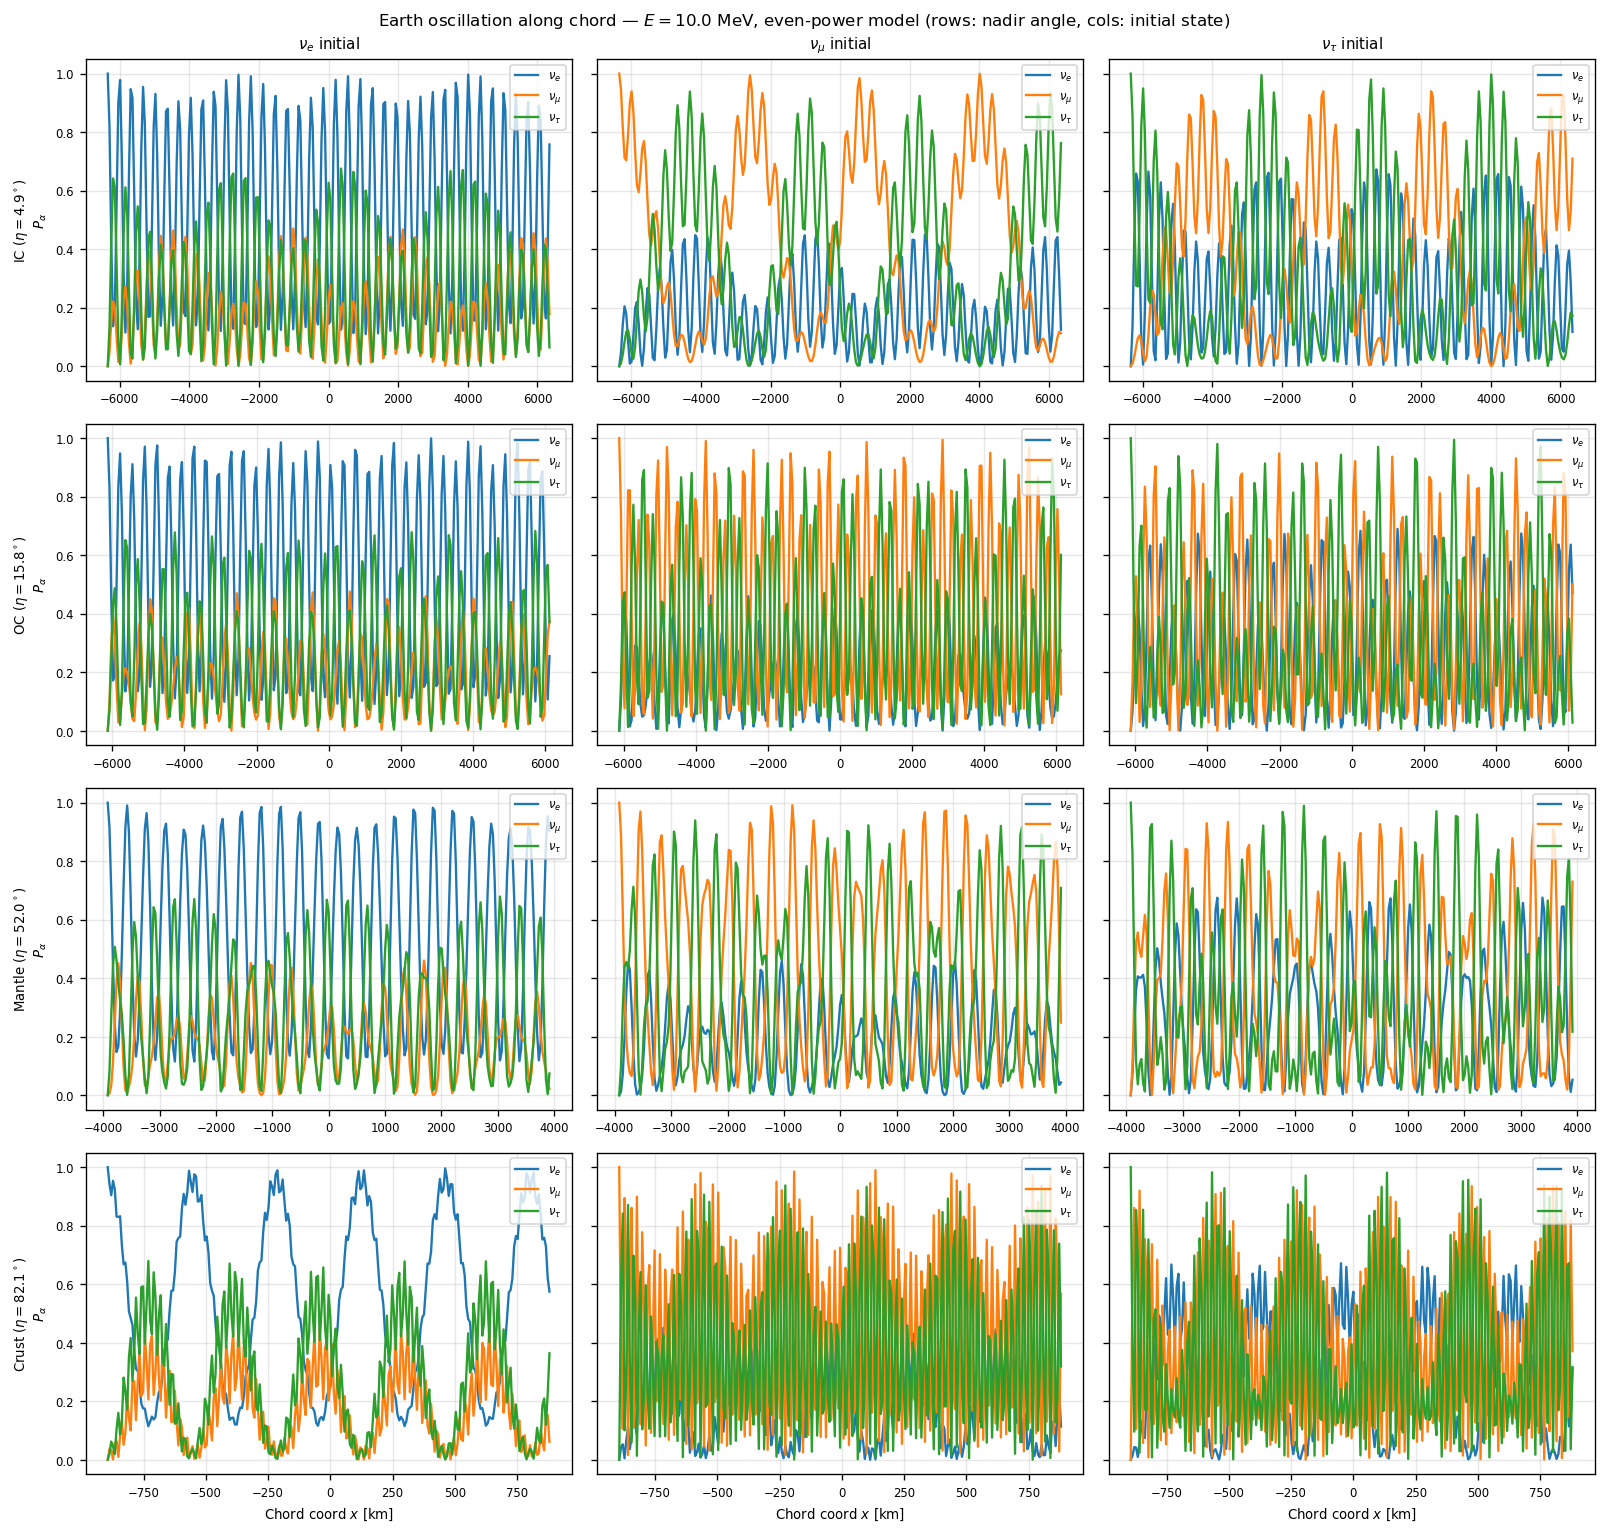

v:\output\analysis\earth\ep2_fig31_chord_all_states.png


In [5]:
TRAJ_E_MEV  = 10.0
TRAJ_NSTEPS = 250
E_t_traj    = torch.tensor(TRAJ_E_MEV, dtype=ctx.dtype, device=ctx.device)

initial_states = [
    (torch.tensor([1., 0., 0.], dtype=CDTYPE, device=ctx.device), r'$\nu_e$ initial'),
    (torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device), r'$\nu_\mu$ initial'),
    (torch.tensor([0., 0., 1.], dtype=CDTYPE, device=ctx.device), r'$\nu_\tau$ initial'),
]

fig, axes = plt.subplots(
    len(NAMED_ETAS), len(initial_states),
    figsize=(13.5, 13.0), sharey=True,
)

for row, (eta_val, eta_label, col_hex) in enumerate(NAMED_ETAS):
    eta_t = torch.tensor(eta_val, dtype=ctx.dtype, device=ctx.device)
    for col_idx, (state, state_label) in enumerate(initial_states):
        ax = axes[row, col_idx]
        sol, x_grid = pearth_numerical(
            state, earth_even, oscillation, E_t_traj, eta_t,
            EARTH_DEPTH_M, massbasis=False, full_oscillation=True,
            nsteps=TRAJ_NSTEPS, ode_method='midpoint', context=ctx,
        )
        x_km  = x_grid.cpu().numpy() * R_E_KM
        sol_np = sol.detach().cpu().numpy()
        for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
            ax.plot(x_km, sol_np[:, f], color=fcol, lw=1.4, label=flabel)
        if row == 0:
            ax.set_title(state_label, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f'{eta_label}\n$P_\\alpha$', fontsize=8)
        if row == len(NAMED_ETAS) - 1:
            ax.set_xlabel('Chord coord $x$ [km]', fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(labelsize=7)

fig.suptitle(
    rf'Earth oscillation along chord — $E={TRAJ_E_MEV}$ MeV, even-power model'
    r' (rows: nadir angle, cols: initial state)',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig31_chord_all_states.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 3.2 Density Profile and Oscillation Overlay

A dual-axis plot for the inner-core trajectory ($\nu_\mu$ initial, $E = 10$ MeV): the three flavour probabilities share the left axis while the electron density $n_e(x)$ is overlaid on the right axis (grey fill). The density jumps at the ICB and CMB are directly visible as discontinuities in the grey curve, and their effect on the oscillation phase is immediate.

The sharp drop at the CMB (where $n_e$ falls by nearly a factor of 2 from outer core to mantle) produces the largest visible phase jump because $V_{\rm CC} \propto n_e$ shifts the effective mixing angle in the Hamiltonian eigenvalue decomposition.

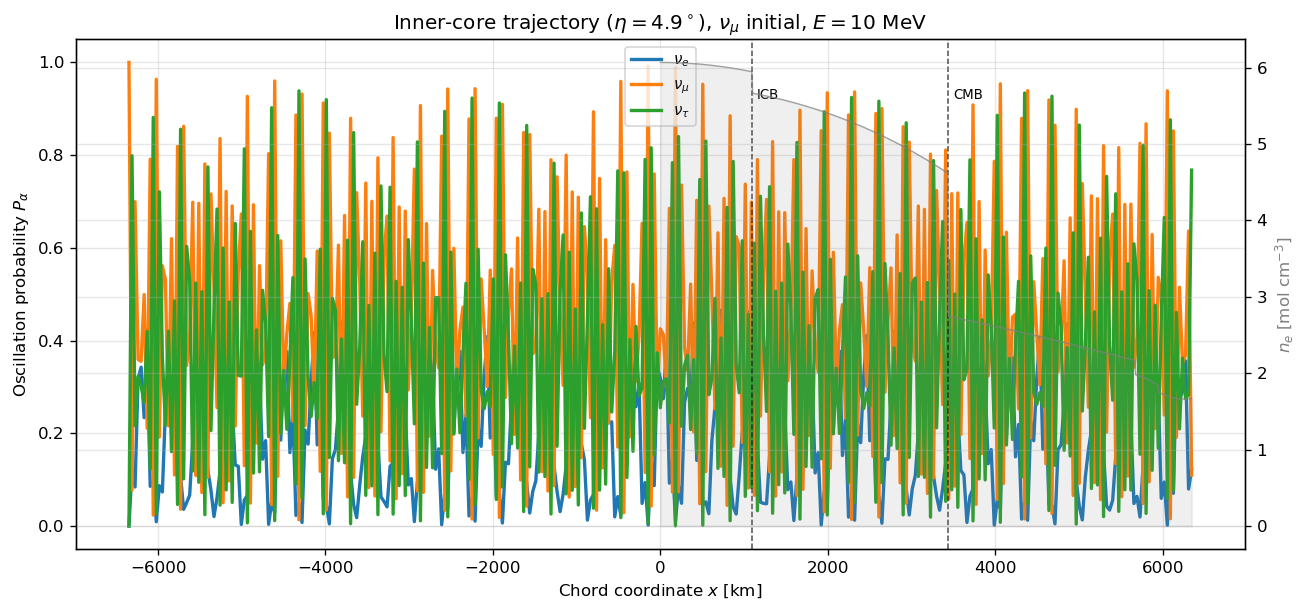

v:\output\analysis\earth\ep2_fig32_chord_overlay.png


In [6]:
eta_t_ic = torch.tensor(eta_ic, dtype=ctx.dtype, device=ctx.device)
E_t_ov   = torch.tensor(10.0,   dtype=ctx.dtype, device=ctx.device)
state_mu = torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device)

sol_ov, x_grid_ov = pearth_numerical(
    state_mu, earth_even, oscillation, E_t_ov, eta_t_ic,
    EARTH_DEPTH_M, massbasis=False, full_oscillation=True,
    nsteps=350, ode_method='midpoint', context=ctx,
)
x_km_ov   = x_grid_ov.cpu().numpy() * R_E_KM
sol_np_ov = sol_ov.detach().cpu().numpy()

x_dense = torch.linspace(
    0.0, float(x_grid_ov[-1]), 600, device=ctx.device, dtype=ctx.dtype,
)
ne_dense = earth_even.density_x_eta(x_dense, eta_t_ic).cpu().numpy()
x_dense_km = x_dense.cpu().numpy() * R_E_KM

# Density jump positions (chord coordinates of ICB and CMB)
x_icb = math.sqrt(max(0.0, (ICB_KM / R_E_KM) ** 2 - math.sin(eta_ic) ** 2))
x_cmb = math.sqrt(max(0.0, (CMB_KM / R_E_KM) ** 2 - math.sin(eta_ic) ** 2))

fig, ax1 = plt.subplots(figsize=(11, 5.2))
ax2 = ax1.twinx()

ax2.fill_between(x_dense_km, ne_dense, alpha=0.12, color='gray')
ax2.plot(x_dense_km, ne_dense, color='gray', lw=0.8, alpha=0.7)
for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
    ax1.plot(x_km_ov, sol_np_ov[:, f], color=fcol, lw=2, label=flabel)

for x_disc, dlabel in [(x_icb * R_E_KM, 'ICB'), (x_cmb * R_E_KM, 'CMB')]:
    ax1.axvline(x_disc, color='black', ls='--', lw=0.9, alpha=0.7)
    ax1.text(x_disc + x_km_ov[-1] * 0.01, 0.92, dlabel, fontsize=8, color='black')

ax1.set_xlabel(r'Chord coordinate $x$ [km]')
ax1.set_ylabel('Oscillation probability $P_\\alpha$')
ax2.set_ylabel(r'$n_e$ [mol cm$^{-3}$]', color='gray')
ax1.set_title(
    rf'Inner-core trajectory ($\eta={math.degrees(eta_ic):.1f}^\circ$), $\nu_\mu$ initial, $E=10$ MeV'
)
ax1.legend(fontsize=9)
fig.tight_layout()
save_and_show('ep2_fig32_chord_overlay.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 3.3 Chord Propagation at Fixed Nadir Angle, Multiple Energies

For fixed inner-core nadir angle ($\eta \approx 5°$) the oscillation pattern along the chord changes dramatically with energy: the oscillation length $L_{\rm osc} \propto E/\Delta m^2$ grows linearly with energy, so higher-energy neutrinos complete fewer oscillation cycles over the same physical path. At low energies the matter term dominates ($V_{\rm CC} \gg \Delta m^2/2E$) and the oscillation is suppressed; at high energies the vacuum mixing is recovered.

**Expected results:**
- At 3 MeV the $\nu_e$ survival probability stays close to 1 (matter suppression).
- At 12–20 MeV the pattern approaches the vacuum oscillation length of $\sim 500$ km.

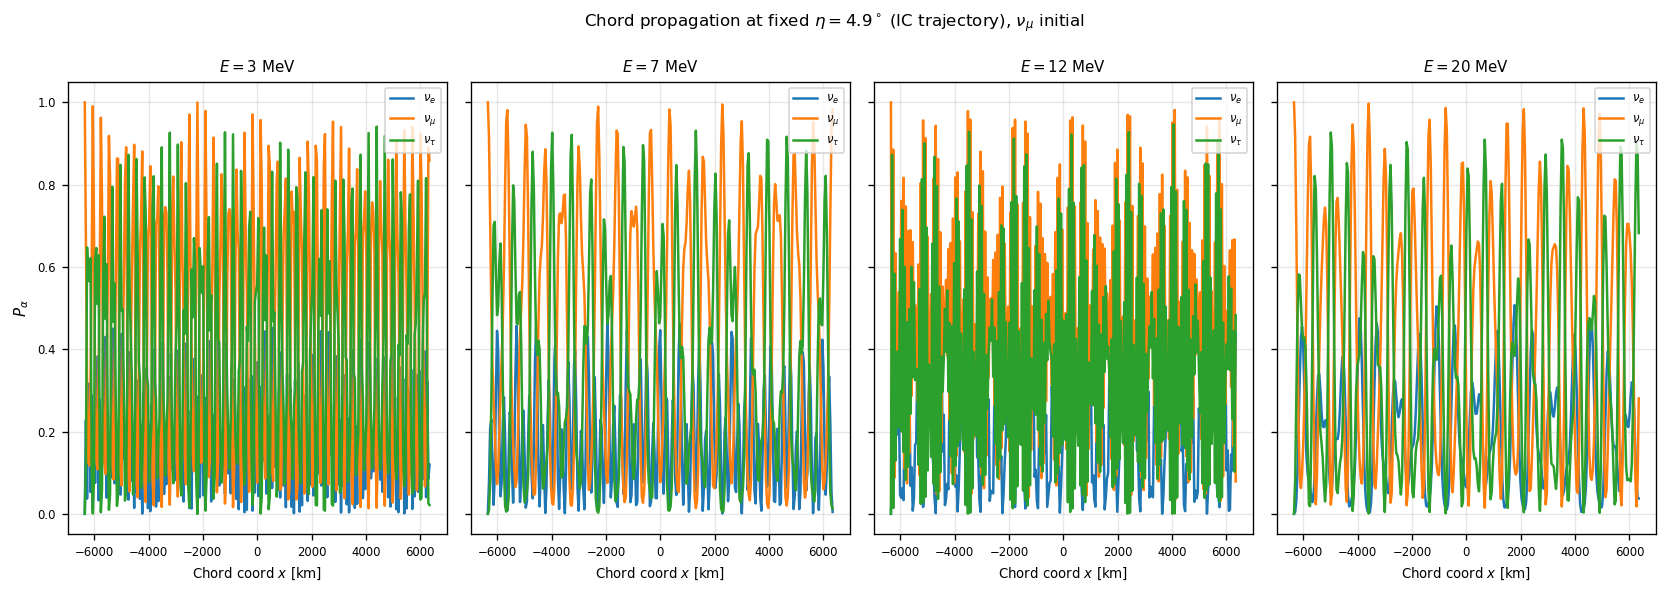

v:\output\analysis\earth\ep2_fig33_chord_vs_energy.png


In [7]:
E_CHORD_MEV = [3.0, 7.0, 12.0, 20.0]
eta_t_ic    = torch.tensor(eta_ic, dtype=ctx.dtype, device=ctx.device)
state_mu    = torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device)

fig, axes = plt.subplots(1, len(E_CHORD_MEV), figsize=(14.0, 5.0),
                         sharey=True, sharex=False)

for ax, E_MeV in zip(axes, E_CHORD_MEV):
    E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    sol, x_grid = pearth_numerical(
        state_mu, earth_even, oscillation, E_t, eta_t_ic,
        EARTH_DEPTH_M, massbasis=False, full_oscillation=True,
        nsteps=300, ode_method='midpoint', context=ctx,
    )
    x_km  = x_grid.cpu().numpy() * R_E_KM
    sol_np = sol.detach().cpu().numpy()
    for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        ax.plot(x_km, sol_np[:, f], color=fcol, lw=1.5, label=flabel)
    ax.set_title(rf'$E = {E_MeV:.0f}$ MeV', fontsize=9)
    ax.set_xlabel('Chord coord $x$ [km]', fontsize=8)
    ax.tick_params(labelsize=7)
    if ax is axes[0]:
        ax.set_ylabel(r'$P_\alpha$', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    rf'Chord propagation at fixed $\eta={math.degrees(eta_ic):.1f}^\circ$ (IC trajectory), $\nu_\mu$ initial',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig33_chord_vs_energy.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 4. Oscillation Probabilities vs Nadir Angle

### 4.1 P vs $\eta$ at Fixed Energies

For three representative energies the $\nu_\mu$ survival and appearance probabilities are shown across the full Earth-crossing range $\eta \in (0, \pi/2)$. The `pearth_analytical` evolutor is used because it is $\mathcal{O}(10\times)$ faster than the numerical one at the same accuracy.

Vertical markers at the critical angles $\eta_{\rm IC}$ and $\eta_{\rm OC}$ mark the thresholds below which the trajectory samples the inner core and outer core, respectively.

**Expected results:**
- Rapid oscillations at low $\eta$ (long chords, dense core).
- Slower modulation at high $\eta$ (short chords through mantle/crust).
- The 3-GeV resonance produces an enhancement in $P_{\mu\to e}$ near the CMB critical angle.

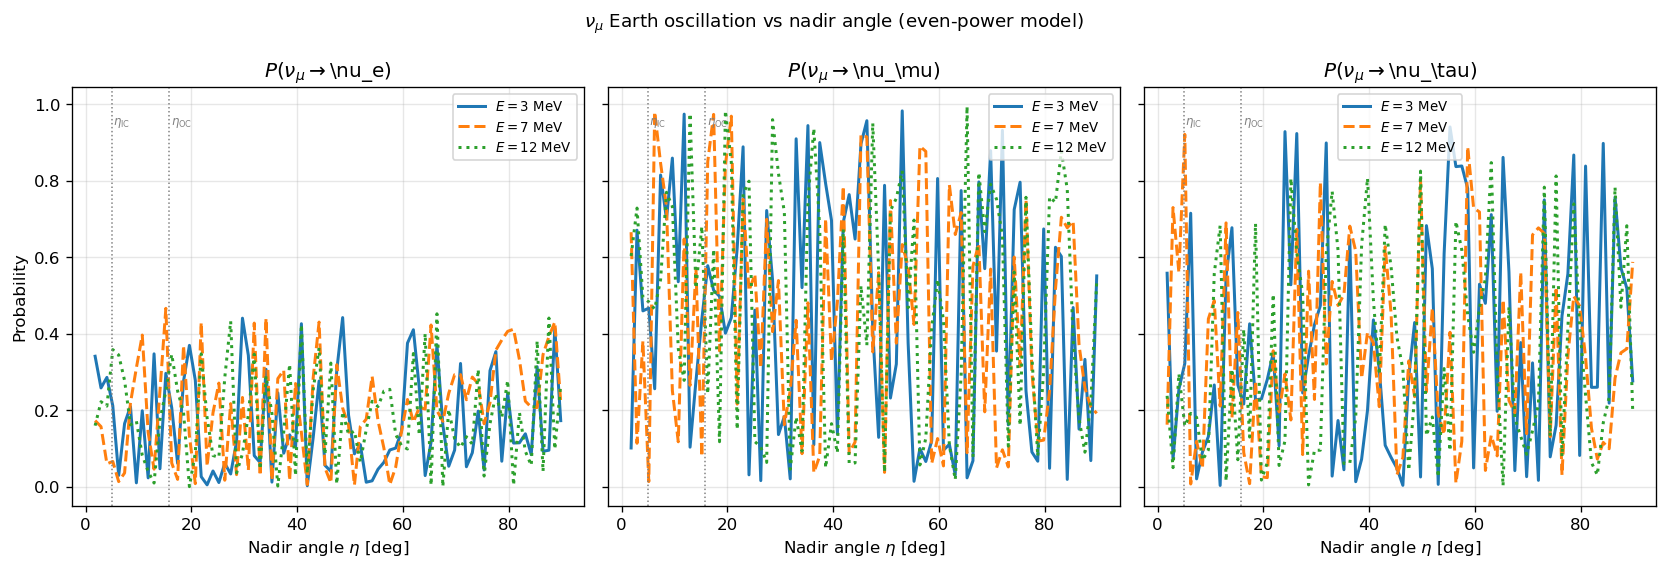

v:\output\analysis\earth\ep2_fig41_p_vs_eta.png


In [8]:
ETA_GRID    = np.linspace(0.01 * math.pi, 0.499 * math.pi, 80)
E_CASES_MEV = [3.0, 7.0, 12.0]
state_mu    = torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device)

P_eta = np.zeros((len(ETA_GRID), len(E_CASES_MEV), 3))
for iE, E_MeV in enumerate(E_CASES_MEV):
    E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    for ie, eta in enumerate(ETA_GRID):
        eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
        P = pearth_analytical(state_mu, earth_even, oscillation, E_t, eta_t,
                              EARTH_DEPTH_M, massbasis=False)
        P_eta[ie, iE] = P.detach().cpu().numpy()

eta_deg = np.degrees(ETA_GRID)
eta_ic_deg  = math.degrees(eta_ic)
eta_oc_deg  = math.degrees(eta_oc)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
for ax, f, flabel in zip(axes, range(3), FLAVOUR_LABELS):
    for iE, (E_MeV, ls) in enumerate(zip(E_CASES_MEV, ['-', '--', ':'])):
        ax.plot(eta_deg, P_eta[:, iE, f], ls=ls, lw=1.8,
                label=rf'$E={E_MeV:.0f}$ MeV')
    for eta_c, dlabel in [(eta_ic_deg, r'$\eta_{\rm IC}$'), (eta_oc_deg, r'$\eta_{\rm OC}$')]:
        ax.axvline(eta_c, color='gray', ls=':', lw=0.9)
        ax.text(eta_c + 0.3, 0.97, dlabel, fontsize=7, color='gray', va='top')
    ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
    ax.set_title(rf'$P(\nu_\mu \to {flabel})$')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Probability')

fig.suptitle(r'$\nu_\mu$ Earth oscillation vs nadir angle (even-power model)', fontsize=11)
fig.tight_layout()
save_and_show('ep2_fig41_p_vs_eta.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 4.2 2D Probability Map $(E, \eta)$ — $\nu_\mu$ Initial

The three $\nu_\mu$-initiated channels as 2D images over the energy–nadir-angle plane. The colour encodes oscillation probability from 0 (dark) to 1 (bright). The resonance bands, the critical-angle thresholds, and the oscillation nodes are all simultaneously visible.

**Expected results:** 
- $P_{\mu\to e}$ shows an enhancement ridge near the CMB critical angle at intermediate energies (MSW Earth resonance).
- $P_{\mu\to\mu}$ shows the complementary suppression.
- The pattern compresses horizontally at low $\eta$ (short oscillation length per unit angle) and stretches at high $\eta$.

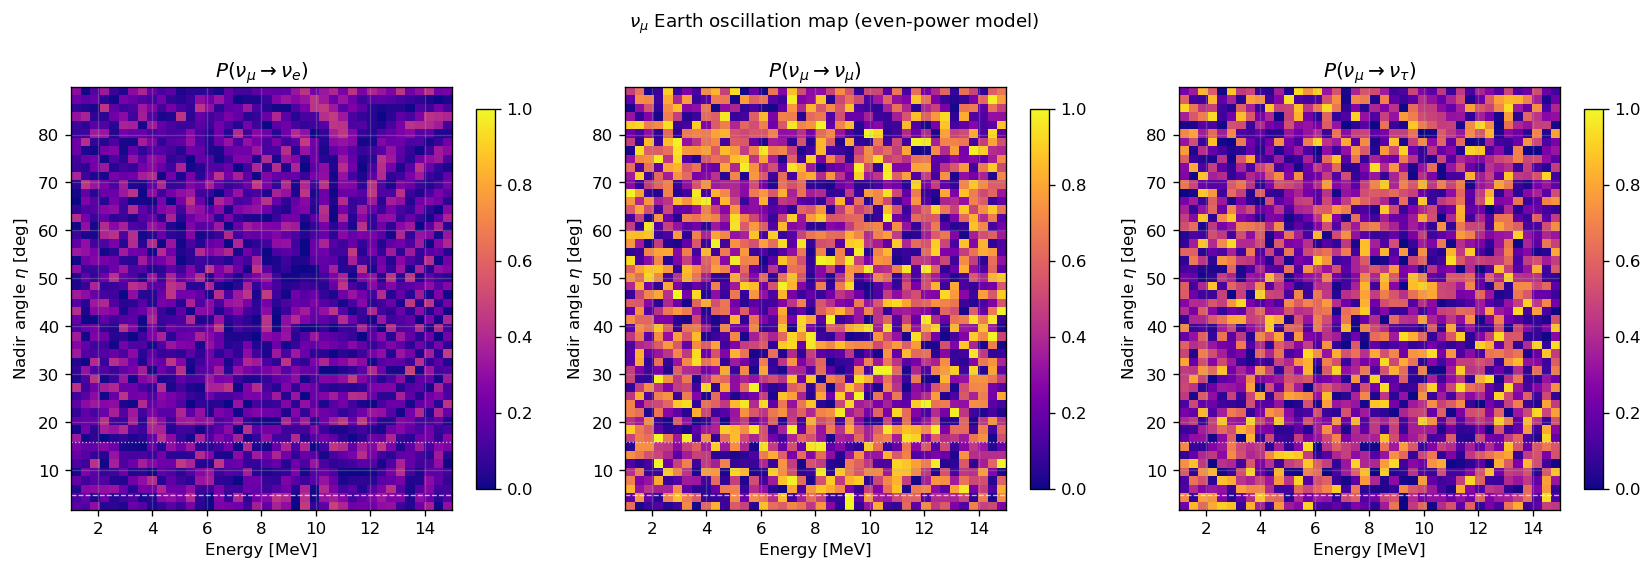

v:\output\analysis\earth\ep2_fig42_map2d.png


In [9]:
E_MAP   = np.linspace(1.0, 15.0, 40)
ETA_MAP = np.linspace(0.01 * math.pi, 0.499 * math.pi, 50)

P_map = np.zeros((len(ETA_MAP), len(E_MAP), 3))
for iE, E_MeV in enumerate(E_MAP):
    E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    for ie, eta in enumerate(ETA_MAP):
        eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
        P = pearth_analytical(state_mu, earth_even, oscillation, E_t, eta_t,
                              EARTH_DEPTH_M, massbasis=False)
        P_map[ie, iE] = P.detach().cpu().numpy()

eta_map_deg = np.degrees(ETA_MAP)
chan_titles = [
    r'$P(\nu_\mu \to \nu_e)$',
    r'$P(\nu_\mu \to \nu_\mu)$',
    r'$P(\nu_\mu \to \nu_\tau)$',
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, f, title in zip(axes, range(3), chan_titles):
    im = ax.imshow(
        P_map[:, :, f], origin='lower', aspect='auto',
        extent=[E_MAP[0], E_MAP[-1], eta_map_deg[0], eta_map_deg[-1]],
        cmap='plasma', vmin=0, vmax=1,
    )
    ax.axhline(eta_ic_deg,  color='white', ls='--', lw=0.8, alpha=0.7)
    ax.axhline(eta_oc_deg,  color='white', ls=':', lw=0.8, alpha=0.7)
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel(r'Nadir angle $\eta$ [deg]')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.9)

fig.suptitle(r'$\nu_\mu$ Earth oscillation map (even-power model)', fontsize=11)
fig.tight_layout()
save_and_show('ep2_fig42_map2d.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 4.3 Full $3\times 3$ Channel Matrix

All nine oscillation channels $P(\nu_\alpha \to \nu_\beta)$ on the same $(E,\eta)$ grid. The 3×3 layout corresponds exactly to the matrix element $|U_{\rm Earth}^{\beta\alpha}|^2$ evaluated at each grid point. Unitarity requires that each row sums to 1 and each column sums to 1 (the latter only approximately in matter, where the Hamiltonian is not symmetric under flavour permutation).

**Expected results:** 
- The diagonal panels ($\nu_\alpha \to \nu_\alpha$) start near 1 and dip at resonance.
- off-diagonal panels are complementary.
- The $\nu_\tau$ row shows the weakest matter dependence since $\tau$ does not appear in the $V_{\rm CC}$ diagonal.

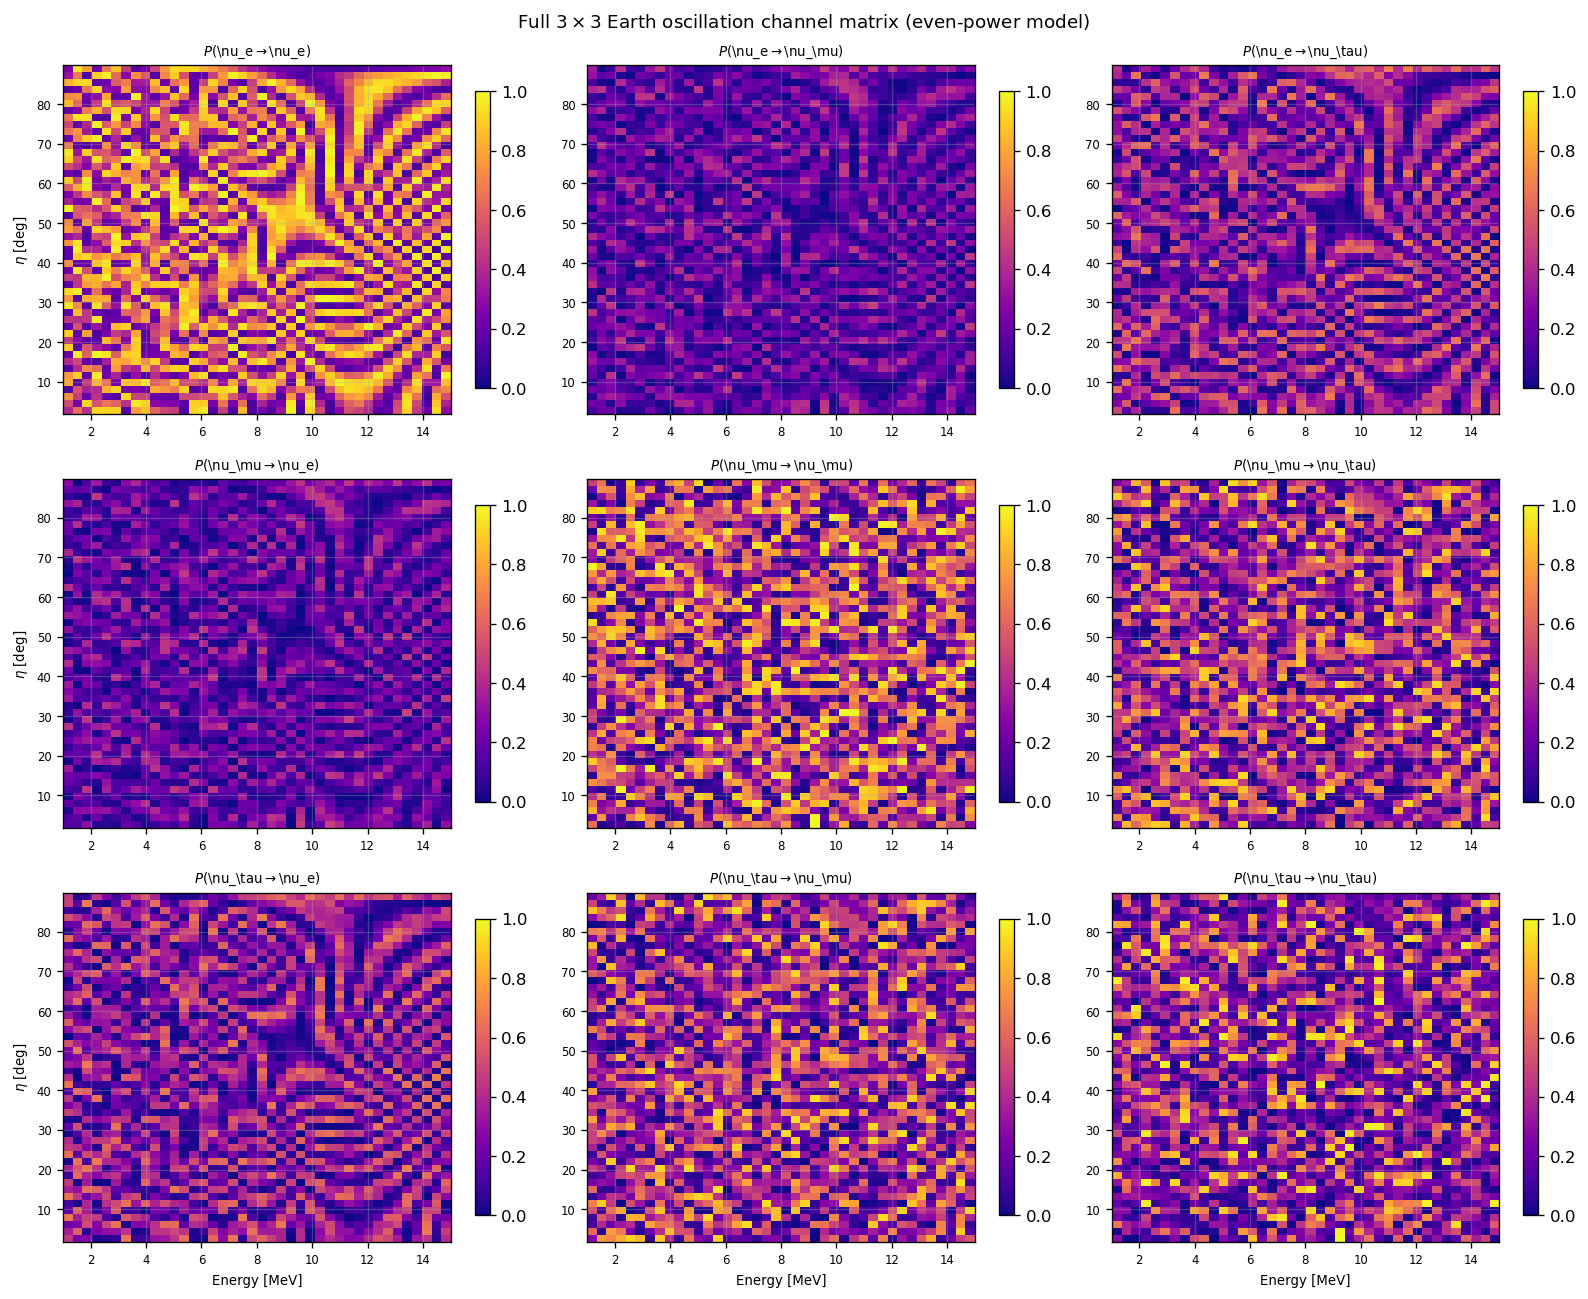

v:\output\analysis\earth\ep2_fig43_map3x3.png
Max |row_sum - 1| (should be ~0): 5.2409e-04


In [10]:
initial_states_3 = [
    torch.tensor([1., 0., 0.], dtype=CDTYPE, device=ctx.device),  # nu_e
    torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device),  # nu_mu
    torch.tensor([0., 0., 1.], dtype=CDTYPE, device=ctx.device),  # nu_tau
]
alpha_labels = [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$']

P_3x3 = np.zeros((3, len(ETA_MAP), len(E_MAP), 3))  # (alpha, eta, E, beta)
for ia, state in enumerate(initial_states_3):
    for iE, E_MeV in enumerate(E_MAP):
        E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
        for ie, eta in enumerate(ETA_MAP):
            eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
            P = pearth_analytical(state, earth_even, oscillation, E_t, eta_t,
                                  EARTH_DEPTH_M, massbasis=False)
            P_3x3[ia, ie, iE] = P.detach().cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(13.5, 11.0))
for ia in range(3):
    for ib in range(3):
        ax = axes[ia, ib]
        im = ax.imshow(
            P_3x3[ia, :, :, ib], origin='lower', aspect='auto',
            extent=[E_MAP[0], E_MAP[-1], eta_map_deg[0], eta_map_deg[-1]],
            cmap='plasma', vmin=0, vmax=1,
        )
        ax.set_title(
            rf'$P({alpha_labels[ia]} \to {alpha_labels[ib]})$',
            fontsize=8,
        )
        if ia == 2:
            ax.set_xlabel('Energy [MeV]', fontsize=8)
        if ib == 0:
            ax.set_ylabel(r'$\eta$ [deg]', fontsize=8)
        ax.tick_params(labelsize=7)
        fig.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle('Full $3\\times 3$ Earth oscillation channel matrix (even-power model)', fontsize=11)
fig.tight_layout()
save_and_show('ep2_fig43_map3x3.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

# Unitarity check: sum over final states
row_sum = P_3x3.sum(axis=3)  # sum over beta -> (3, n_eta, n_E)
print(f'Max |row_sum - 1| (should be ~0): {np.max(np.abs(row_sum - 1.0)):.4e}')

## 5. Energy Dependence

### 5.1 Oscillation Probabilities vs Energy

For each of the four representative nadir angles, $P$ is shown as a function of energy for both $\nu_e$ and $\nu_\mu$ initial states. The 2×4 panel grid allows direct comparison of how the resonance structure and oscillation frequency change between the core-crossing and mantle-crossing geometries.

**Expected results:** 
- Inner-core trajectories (top row) show faster oscillation (shorter $L/E$); mantle trajectories (bottom rows) show coarser fringes.
- The MSW resonance at the outer-core CMB crossing appears as a broad enhancement in $P_{e\to e}$ dip and $P_{\mu\to e}$ peak around 3–7 MeV for the OC trajectory.

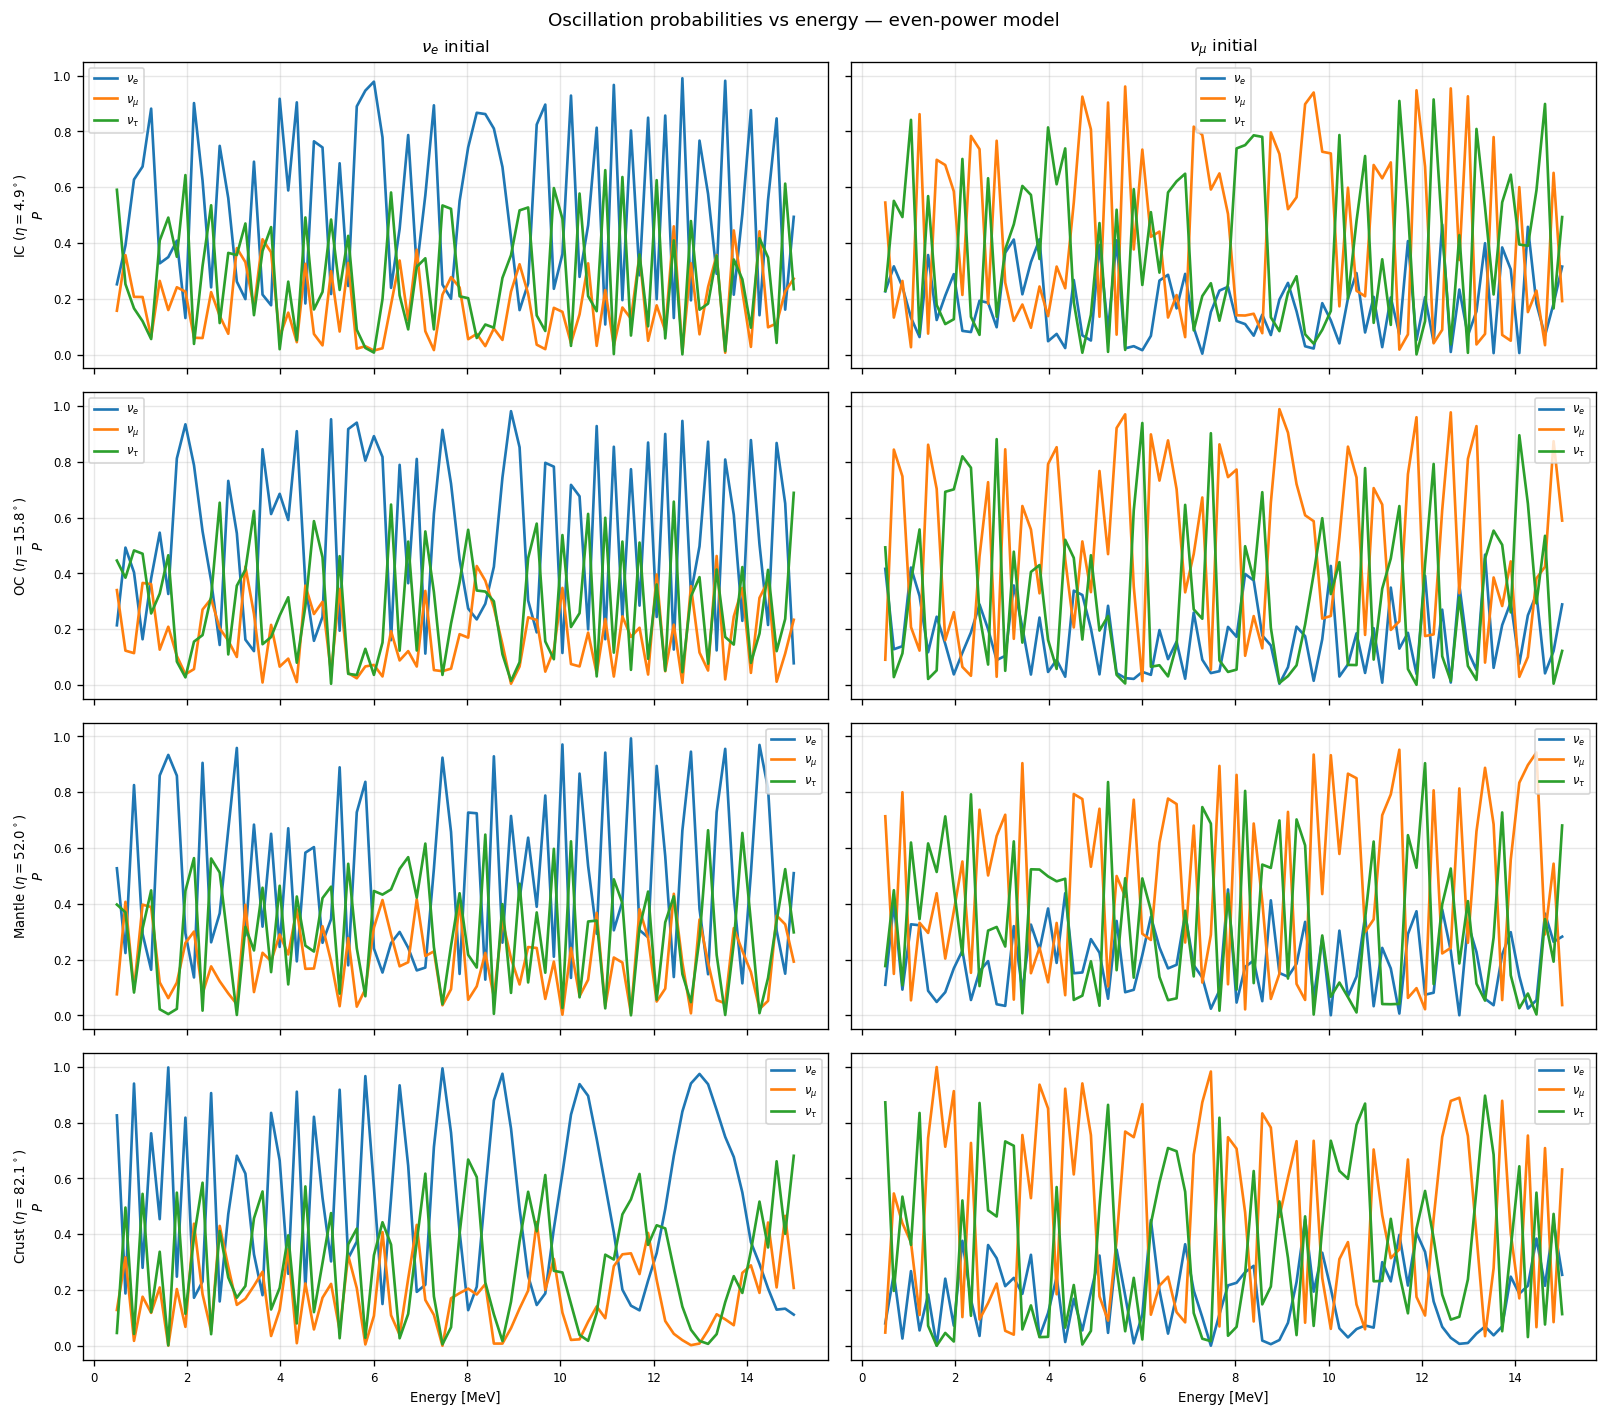

v:\output\analysis\earth\ep2_fig51_p_vs_e.png


In [11]:
E_FINE      = np.linspace(0.5, 15.0, 80)
state_e     = torch.tensor([1., 0., 0.], dtype=CDTYPE, device=ctx.device)
state_mu_t  = torch.tensor([0., 1., 0.], dtype=CDTYPE, device=ctx.device)

P_vs_E = {}
for init_label, state in [('nue', state_e), ('numu', state_mu_t)]:
    P_arr = np.zeros((len(NAMED_ETAS), len(E_FINE), 3))
    for ie, (eta_val, _, _) in enumerate(NAMED_ETAS):
        eta_t = torch.tensor(eta_val, dtype=ctx.dtype, device=ctx.device)
        for iE, E_MeV in enumerate(E_FINE):
            E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
            P = pearth_analytical(state, earth_even, oscillation, E_t, eta_t,
                                  EARTH_DEPTH_M, massbasis=False)
            P_arr[ie, iE] = P.detach().cpu().numpy()
    P_vs_E[init_label] = P_arr

fig, axes = plt.subplots(
    len(NAMED_ETAS), 2, figsize=(13.5, 12.0), sharey=True, sharex=True,
)
for row, (eta_val, eta_label, _) in enumerate(NAMED_ETAS):
    for col, (init_label, state_label) in enumerate(
        [('nue', r'$\nu_e$ initial'), ('numu', r'$\nu_\mu$ initial')]
    ):
        ax = axes[row, col]
        for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
            ax.plot(E_FINE, P_vs_E[init_label][row, :, f],
                    color=fcol, lw=1.6, label=flabel)
        if row == 0:
            ax.set_title(state_label, fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{eta_label}\n$P$', fontsize=8)
        if row == len(NAMED_ETAS) - 1:
            ax.set_xlabel('Energy [MeV]', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle('Oscillation probabilities vs energy — even-power model', fontsize=11)
fig.tight_layout()
save_and_show('ep2_fig51_p_vs_e.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 6. Methods and Numerical Accuracy

### 6.1 Analytical vs Numerical Method Comparison

`pearth_analytical` uses the perturbative closed-form evolutor; `pearth_numerical` integrates the Schrödinger equation directly with `nsteps` equal segments. The maximum relative difference $\delta P = |P_{\rm an} - P_{\rm num}| / \max(P_{\rm num}, 10^{-4})$ is computed over the energy grid for three nadir angles and shown as a function of energy.

**Expected results:** 
- Relative errors below $10^{-3}$ for most (E,η), growing near resonance or at the inner-core boundary where the density gradient is large.

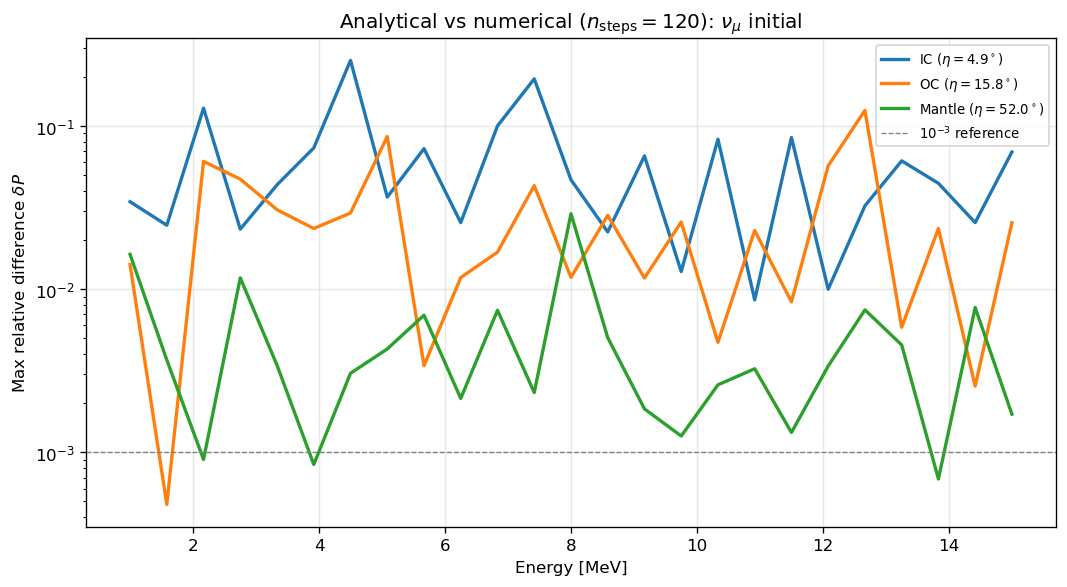

v:\output\analysis\earth\ep2_fig61_method_comp.png
Max |delta_P| over all cases: 2.517e-01
  IC ($\eta=4.9^\circ$): max = 2.517e-01
  OC ($\eta=15.8^\circ$): max = 1.243e-01
  Mantle ($\eta=52.0^\circ$): max = 2.896e-02


In [12]:
COMP_E_MEV  = np.linspace(1.0, 15.0, 25)
COMP_ETAS   = [eta_ic, eta_oc, eta_mantle]
COMP_LABELS = [
    rf'IC ($\eta={math.degrees(eta_ic):.1f}^\circ$)',
    rf'OC ($\eta={math.degrees(eta_oc):.1f}^\circ$)',
    rf'Mantle ($\eta={math.degrees(eta_mantle):.1f}^\circ$)',
]
COMP_NSTEPS = 120

max_rel_diff = np.zeros((len(COMP_ETAS), len(COMP_E_MEV)))
for ie, eta in enumerate(COMP_ETAS):
    eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
    for iE, E_MeV in enumerate(COMP_E_MEV):
        E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
        P_an  = pearth_analytical(state_mu, earth_even, oscillation, E_t, eta_t,
                                  EARTH_DEPTH_M, massbasis=False).detach().cpu().numpy()
        P_num = pearth_numerical(state_mu, earth_even, oscillation, E_t, eta_t,
                                 EARTH_DEPTH_M, massbasis=False,
                                 nsteps=COMP_NSTEPS, ode_method='midpoint',
                                 context=ctx).detach().cpu().numpy()
        denom = np.maximum(P_num, 1e-4)
        max_rel_diff[ie, iE] = np.max(np.abs(P_an - P_num) / denom)

fig, ax = plt.subplots(figsize=(9, 5.0))
for ie, (label, col) in enumerate(zip(COMP_LABELS, ['C0', 'C1', 'C2'])):
    ax.semilogy(COMP_E_MEV, max_rel_diff[ie], color=col, lw=2, label=label)

ax.axhline(1e-3, color='gray', ls='--', lw=0.8, label=r'$10^{-3}$ reference')
ax.set_xlabel('Energy [MeV]')
ax.set_ylabel(r'Max relative difference $\delta P$')
ax.set_title(
    rf'Analytical vs numerical ($n_{{\rm steps}}={COMP_NSTEPS}$): $\nu_\mu$ initial'
)
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show('ep2_fig61_method_comp.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |delta_P| over all cases: {max_rel_diff.max():.3e}')
for ie, label in enumerate(COMP_LABELS):
    print(f'  {label}: max = {max_rel_diff[ie].max():.3e}')

### 6.2 Unitarity Deviation and the `reunitarize` Flag

The perturbative evolutor is not guaranteed to be exactly unitary because it truncates the Magnus expansion within each shell. The unitarity deviation $\epsilon_U = \| U^\dagger U - I \|_F / 3$ measures how far the computed evolution operator is from a unitary matrix. Setting `reunitarize=True` projects $U$ onto the nearest unitary matrix (Procrustes problem), reducing the error at the cost of a small additional computation.

**Expected results:** 
- $\epsilon_U$ grows with energy and with inner-core depth (where the potential is largest).
- The `reunitarize` projection suppresses $\epsilon_U$ by orders of magnitude and has negligible effect on the physical probabilities when $\epsilon_U$ is already small.

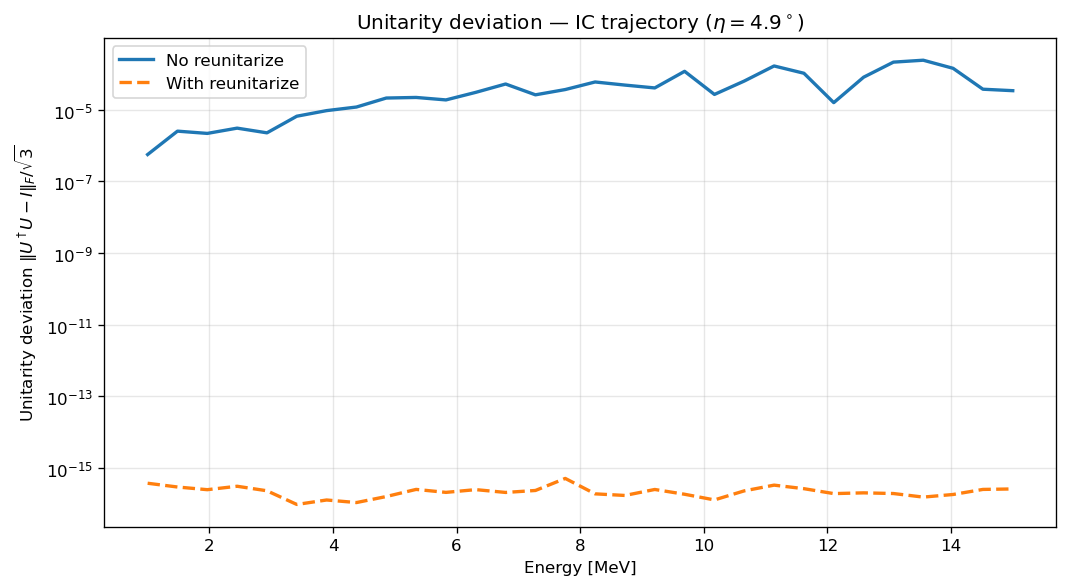

v:\output\analysis\earth\ep2_fig62_reunitarize.png
Max epsilon (plain)     : 2.395e-04
Max epsilon (reunitarize): 5.128e-16


In [13]:
from tpeanuts.medium.earth.evolutor import earth_evolutor

E_RUNIT  = np.linspace(1.0, 15.0, 30)
eta_t_ic = torch.tensor(eta_ic, dtype=ctx.dtype, device=ctx.device)

eps_plain  = np.zeros(len(E_RUNIT))
eps_reunit = np.zeros(len(E_RUNIT))

for iE, E_MeV in enumerate(E_RUNIT):
    E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    U_p = earth_evolutor(earth_even, oscillation, E_t, eta_t_ic,
                         EARTH_DEPTH_M, reunitarize=False)
    U_r = earth_evolutor(earth_even, oscillation, E_t, eta_t_ic,
                         EARTH_DEPTH_M, reunitarize=True)
    for eps_arr, U in [(eps_plain, U_p), (eps_reunit, U_r)]:
        UdU = torch.matmul(U.conj().transpose(-1, -2), U)
        I   = torch.eye(3, dtype=UdU.dtype, device=UdU.device)
        eps_arr[iE] = float((UdU - I).abs().pow(2).mean().sqrt())

fig, ax = plt.subplots(figsize=(9, 5.0))
ax.semilogy(E_RUNIT, eps_plain,  'C0', lw=2, label='No reunitarize')
ax.semilogy(E_RUNIT, eps_reunit, 'C1', lw=2, ls='--', label='With reunitarize')
ax.set_xlabel('Energy [MeV]')
ax.set_ylabel(r'Unitarity deviation $\|U^\dagger U - I\|_F / \sqrt{3}$')
ax.set_title(
    rf'Unitarity deviation — IC trajectory ($\eta={math.degrees(eta_ic):.1f}^\circ$)'
)
ax.legend()
fig.tight_layout()
save_and_show('ep2_fig62_reunitarize.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max epsilon (plain)     : {eps_plain.max():.3e}')
print(f'Max epsilon (reunitarize): {eps_reunit.max():.3e}')

## 7. Evolution Operator

### 7.1 $|U_{\alpha\beta}|^2$ vs Energy at Fixed Nadir Angle

`earth_evolutor` returns the full $3\times 3$ complex evolution matrix $U_{\rm Earth}(E,\eta)$ in the flavour basis. For independent 1D grids of $E$ and $\eta$ the output has shape `(nE, nEta, 3, 3)`, giving direct access to all matrix elements without looping.

At fixed nadir angle the 9 curves $|U_{\alpha\beta}(E)|^2$ encode the same information as the 9 probability channels of §4.3, but derived from the operator rather than from state-vector propagation. The probability for initial state $|\alpha\rangle$ reaching $|\beta\rangle$ is $P_{\alpha\to\beta} = |U_{\beta\alpha}|^2$.

**Expected results:** 
- The diagonal elements oscillate about their vacuum values;
- At zero matter potential ($E\to\infty$) they would recover the vacuum $|U^{\rm PMNS}_{\alpha\beta}|^2$ independent of $\eta$.

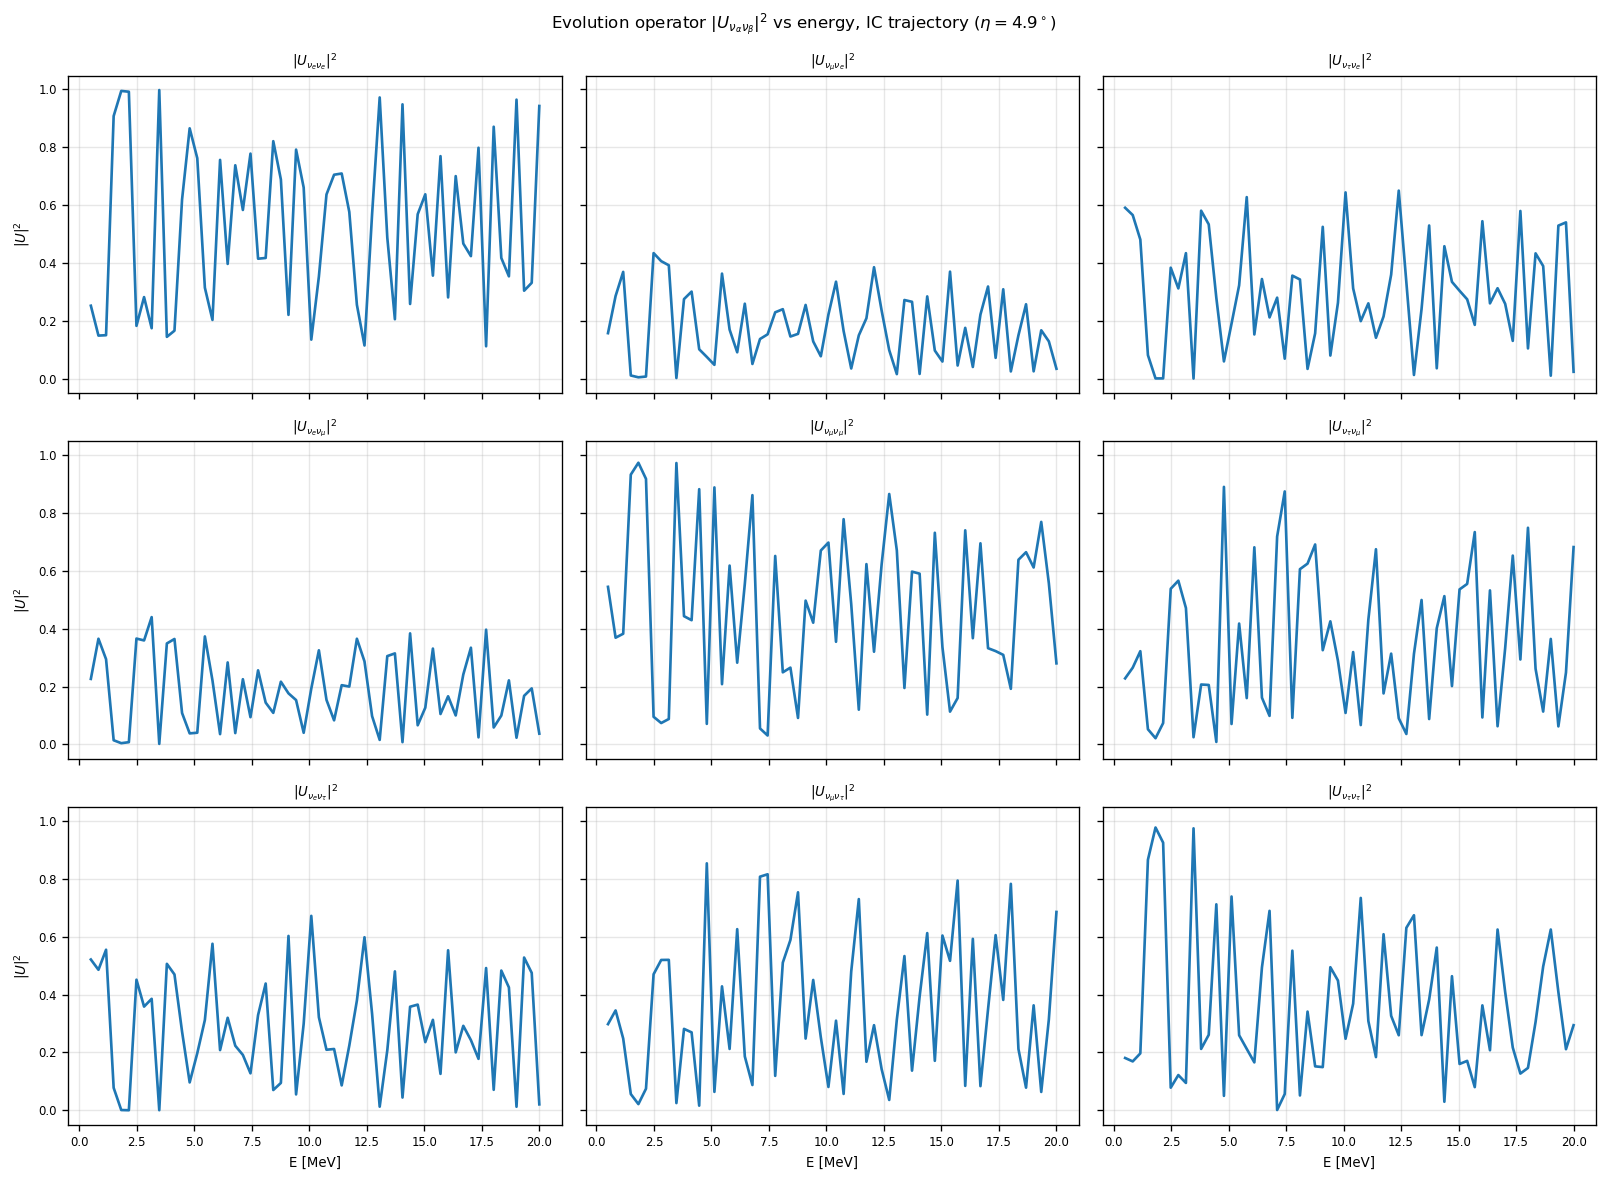

v:\output\analysis\earth\ep2_fig71_evolutor_vs_e.png


In [14]:
E_EVOL    = torch.linspace(0.5, 20.0, 60, dtype=ctx.dtype, device=ctx.device)
eta_t_ic  = torch.tensor(eta_ic, dtype=ctx.dtype, device=ctx.device)

# Output shape: (60, 3, 3) complex  (0-D eta broadcasts with 1-D E)
U_vs_E = earth_evolutor(earth_even, oscillation, E_EVOL, eta_t_ic, EARTH_DEPTH_M)
U_abs2_E = U_vs_E.abs().pow(2).cpu().numpy()  # (60, 3, 3)
E_evol_np = E_EVOL.cpu().numpy()

FSUB = ['e', r'\mu', r'\tau']  # flavour subscript strings

fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.0), sharex=True, sharey=True)
for ab in range(3):
    for bb in range(3):
        ax = axes[ab, bb]
        ax.plot(E_evol_np, U_abs2_E[:, bb, ab], 'C0', lw=1.6)
        ax.set_title(
            r'$|U_{\nu_{' + FSUB[bb] + r'}\nu_{' + FSUB[ab] + r'}}|^2$',
            fontsize=8,
        )
        if ab == 2:
            ax.set_xlabel('E [MeV]', fontsize=8)
        if bb == 0:
            ax.set_ylabel(r'$|U|^2$', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle(
    r'Evolution operator $|U_{\nu_\alpha \nu_\beta}|^2$ vs energy'
    + rf', IC trajectory ($\eta = {math.degrees(eta_ic):.1f}^\circ$)',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig71_evolutor_vs_e.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 7.2 $|U_{\alpha\beta}|^2$ vs Nadir Angle at Fixed Energy

At fixed energy the evolution operator transitions from the full-matter regime (small $\eta$, long chords through dense core) to the vacuum limit (large $\eta \to \pi/2$, zero path length). At $\eta = \pi/2$ the chord length is zero so $U = I$ and there is no oscillation. The 2D map $|U_{\alpha\beta}|^2(E, \eta)$ from `earth_evolutor` on independent grids visualises this transition for all 9 matrix elements simultaneously.

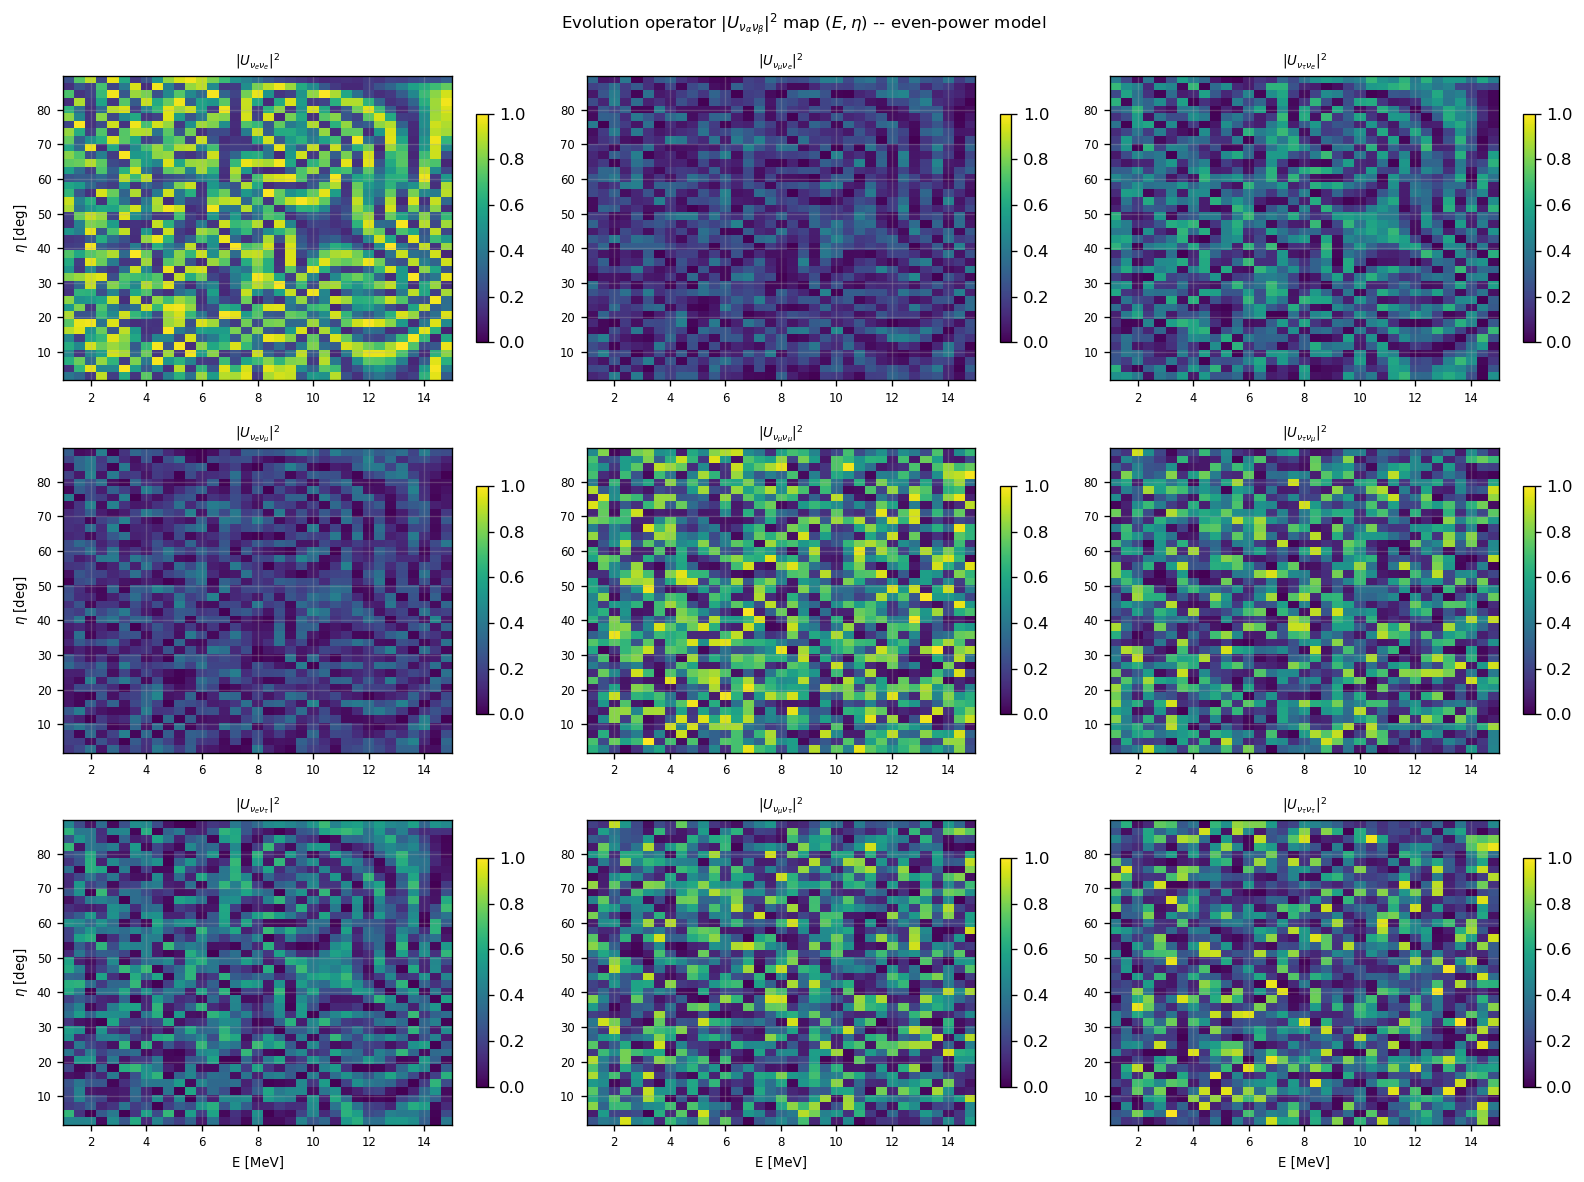

v:\output\analysis\earth\ep2_fig72_evolutor_2d.png


In [15]:
E_EVOL2   = torch.linspace(1.0, 15.0, 35, dtype=ctx.dtype, device=ctx.device)
ETA_EVOL  = torch.linspace(0.01 * math.pi, 0.499 * math.pi, 40,
                            dtype=ctx.dtype, device=ctx.device)

# shape: (35, 40, 3, 3) complex  -- independent_1d grid
U_2d = earth_evolutor(earth_even, oscillation, E_EVOL2, ETA_EVOL, EARTH_DEPTH_M)
U_abs2_2d = U_2d.abs().pow(2).cpu().numpy()  # (35, 40, 3, 3)
E2_np     = E_EVOL2.cpu().numpy()
eta2_deg  = np.degrees(ETA_EVOL.cpu().numpy())

if 'FSUB' not in dir():
    FSUB = ['e', r'\mu', r'\tau']

fig, axes = plt.subplots(3, 3, figsize=(13.5, 10.0))
for ab in range(3):
    for bb in range(3):
        ax = axes[ab, bb]
        im = ax.imshow(
            U_abs2_2d[:, :, bb, ab].T,  # (eta, E) -> transpose -> (y=eta, x=E)
            origin='lower', aspect='auto',
            extent=[E2_np[0], E2_np[-1], eta2_deg[0], eta2_deg[-1]],
            cmap='viridis', vmin=0, vmax=1,
        )
        ax.set_title(
            r'$|U_{\nu_{' + FSUB[bb] + r'}\nu_{' + FSUB[ab] + r'}}|^2$',
            fontsize=8,
        )
        if ab == 2:
            ax.set_xlabel('E [MeV]', fontsize=8)
        if bb == 0:
            ax.set_ylabel(r'$\eta$ [deg]', fontsize=8)
        ax.tick_params(labelsize=7)
        fig.colorbar(im, ax=ax, shrink=0.75)

fig.suptitle(
    r'Evolution operator $|U_{\nu_\alpha \nu_\beta}|^2$ map $(E,\eta)$ -- even-power model',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig72_evolutor_2d.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 7.3 Zenith-Angle Interface: `earth_evolutor_from_zenith`

`earth_evolutor_from_zenith(profile, oscillation, E_MeV, theta_deg, depth_m)` is a convenience wrapper for experiments or event generators that use the detector zenith angle $\theta$ (angle from the upward vertical) instead of the nadir angle $\eta = \pi/2 - \theta$ used internally. Both functions are mathematically equivalent; this cell verifies that they agree and shows the $|U|^2$ diagonal at a fixed energy for a sweep of zenith angles.

The nadir angle $\eta$ and zenith angle $\theta$ are related by $\eta + \theta = 90°$, so $\theta = 90°$ corresponds to a horizontal (no-Earth-crossing) trajectory.

Max |U_zenith - U_nadir| : 0.000e+00  (should be ~0)


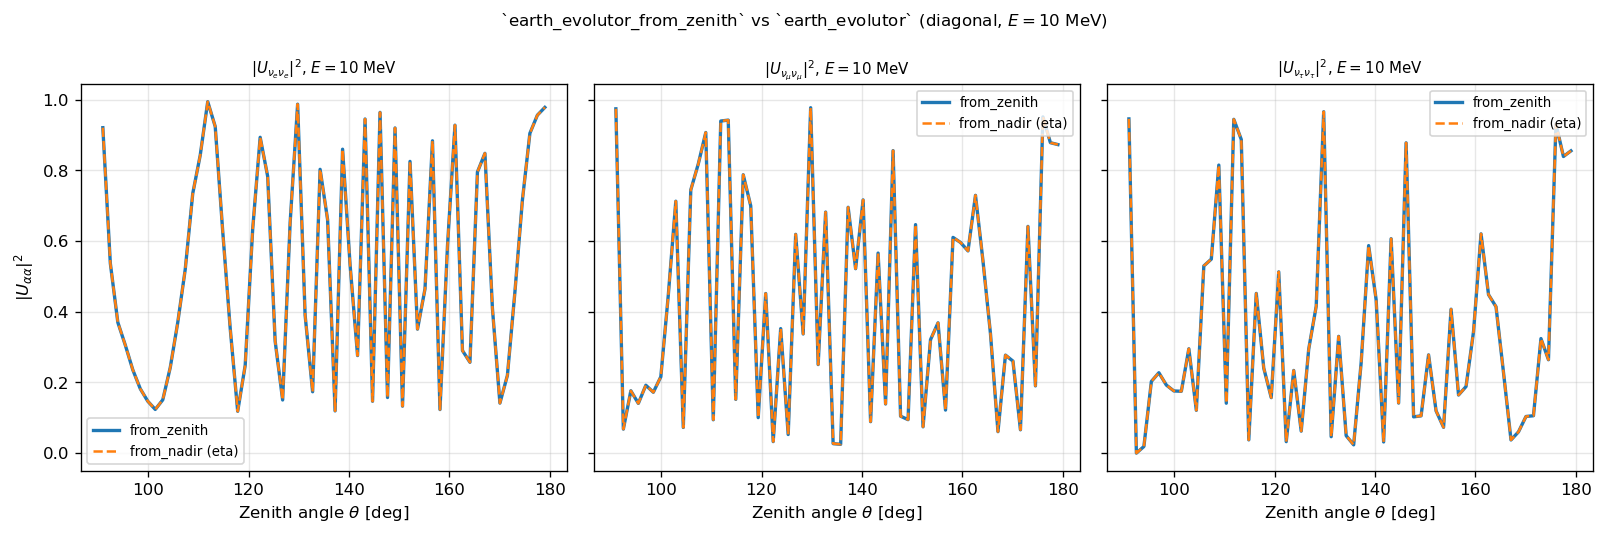

v:\output\analysis\earth\ep2_fig73_evolutor_zenith.png


In [16]:
E_ZEN  = torch.tensor(10.0, dtype=ctx.dtype, device=ctx.device)

# Upward-going neutrinos: theta in (90, 180) means coming from below
# earth_evolutor_from_zenith uses:  eta = pi - radians(theta)
THETA_DEG = np.linspace(91.0, 179.0, 60)      # 91 deg (near horizon) to 179 deg (near vertical)
ETA_RAD   = np.pi - np.radians(THETA_DEG)     # equivalent nadir angle: eta = pi - theta_rad

U_zen  = np.zeros((60, 3, 3), dtype=complex)
U_nadir= np.zeros((60, 3, 3), dtype=complex)

for i, (theta_d, eta_rad) in enumerate(zip(THETA_DEG, ETA_RAD)):
    theta_t = torch.tensor(theta_d,    dtype=ctx.dtype, device=ctx.device)
    eta_t   = torch.tensor(float(eta_rad), dtype=ctx.dtype, device=ctx.device)

    U_z = earth_evolutor_from_zenith(
        earth_even, oscillation, E_ZEN, theta_t, EARTH_DEPTH_M,
    )
    U_n = earth_evolutor(
        earth_even, oscillation, E_ZEN, eta_t, EARTH_DEPTH_M,
    )
    U_zen[i]   = U_z.cpu().numpy()
    U_nadir[i] = U_n.cpu().numpy()

max_diff = np.max(np.abs(U_zen - U_nadir))
print(f'Max |U_zenith - U_nadir| : {max_diff:.3e}  (should be ~0)')

_fsub = ['e', r'\mu', r'\tau']  # flavour subscripts

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5), sharey=True)
for ax, b, flabel in zip(axes, range(3), FLAVOUR_LABELS):
    ax.plot(THETA_DEG, np.abs(U_zen[:, b, b]) ** 2,
            'C0', lw=2, label='from_zenith')
    ax.plot(THETA_DEG, np.abs(U_nadir[:, b, b]) ** 2,
            'C1--', lw=1.5, label='from_nadir (eta)')
    ax.set_xlabel(r'Zenith angle $\theta$ [deg]')
    ax.set_title(
        r'$|U_{\nu_{' + _fsub[b] + r'}\nu_{' + _fsub[b] + r'}}|^2$, $E=10$ MeV',
        fontsize=9,
    )
    ax.legend(fontsize=8)
axes[0].set_ylabel(r'$|U_{\alpha\alpha}|^2$')

fig.suptitle(
    r'`earth_evolutor_from_zenith` vs `earth_evolutor` (diagonal, $E=10$ MeV)',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig73_evolutor_zenith.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 8. Density Model Comparison

### 8.1 Probability Difference: PREM500 − Even-Power

The two Earth density models produce slightly different probabilities. The difference $\Delta P = P^{\rm PREM} - P^{\rm even}$ on the $(E,\eta)$ grid quantifies how much the choice of density model affects the oscillation prediction. The even-power model smooths the density discontinuities, while PREM500 reproduces every tabulated jump.

**Expected results:**
- Largest $|\Delta P| < 0.05$ near the inner-core critical angle $\eta_{\rm IC}$ and at intermediate energies (3–7 MeV) where the resonance is sensitive to the exact density profile near the ICB.
- The mantle region shows smaller differences because both models agree well there.

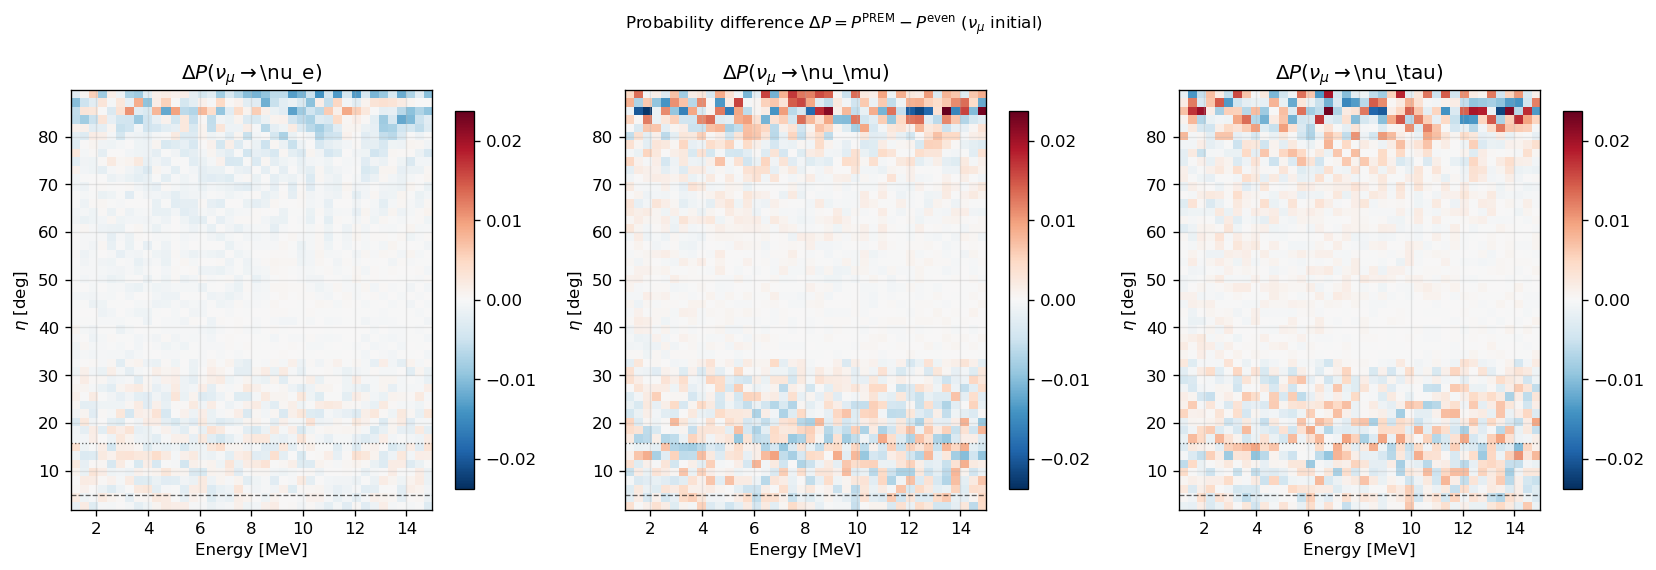

v:\output\analysis\earth\ep2_fig91_model_diff.png
Max |delta_P|          : 0.0238
RMS delta_P (all chan.) : 0.0033


In [17]:
P_map_prem = np.zeros_like(P_map)
for iE, E_MeV in enumerate(E_MAP):
    E_t = torch.tensor(E_MeV, dtype=ctx.dtype, device=ctx.device)
    for ie, eta in enumerate(ETA_MAP):
        eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
        P = pearth_analytical(state_mu, earth_prem, oscillation, E_t, eta_t,
                              EARTH_DEPTH_M, massbasis=False)
        P_map_prem[ie, iE] = P.detach().cpu().numpy()

delta_P = P_map_prem - P_map  # (n_eta, n_E, 3)
vabs    = np.max(np.abs(delta_P))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, f, title in zip(
    axes, range(3),
    [r'$\nu_e$', r'$\nu_\mu$', r'$\nu_\tau$'],
):
    im = ax.imshow(
        delta_P[:, :, f], origin='lower', aspect='auto',
        extent=[E_MAP[0], E_MAP[-1], eta_map_deg[0], eta_map_deg[-1]],
        cmap='RdBu_r', vmin=-vabs, vmax=vabs,
    )
    ax.axhline(eta_ic_deg, color='black', ls='--', lw=0.8, alpha=0.6)
    ax.axhline(eta_oc_deg, color='black', ls=':', lw=0.8, alpha=0.6)
    ax.set_xlabel('Energy [MeV]')
    ax.set_ylabel(r'$\eta$ [deg]')
    ax.set_title(rf'$\Delta P(\nu_\mu \to {title})$')
    fig.colorbar(im, ax=ax, shrink=0.9)

fig.suptitle(
    r'Probability difference $\Delta P = P^{\rm PREM} - P^{\rm even}$ ($\nu_\mu$ initial)',
    fontsize=10,
)
fig.tight_layout()
save_and_show('ep2_fig91_model_diff.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'Max |delta_P|          : {vabs:.4f}')
print(f'RMS delta_P (all chan.) : {np.sqrt(np.mean(delta_P**2)):.4f}')

## 9. Detector Depth Effect

### 9.1 Probability vs Detector Depth at Fixed $(E, \eta)$

A detector buried at depth $d$ below the Earth surface has a shorter effective chord: the neutrino enters the Earth surface and travels to the detector at $r_d = R_\oplus - d$. The probability at fixed $(E, \eta)$ oscillates as a function of $d$ because the last segment of the path — from the outer Earth shell to the detector — changes length.

Two representative cases are shown: a mantle trajectory at moderate energy (where the oscillation length is short) and an outer-core trajectory at higher energy.

**Expected results:** 
- The probability modulates approximately sinusoidally in $d$ with a period $\sim L_{\rm osc}/2$.
- For $d \lesssim 5$ km the variation is negligible.
- It becomes significant for deep underground or underwater detectors ($d > 1$ km).

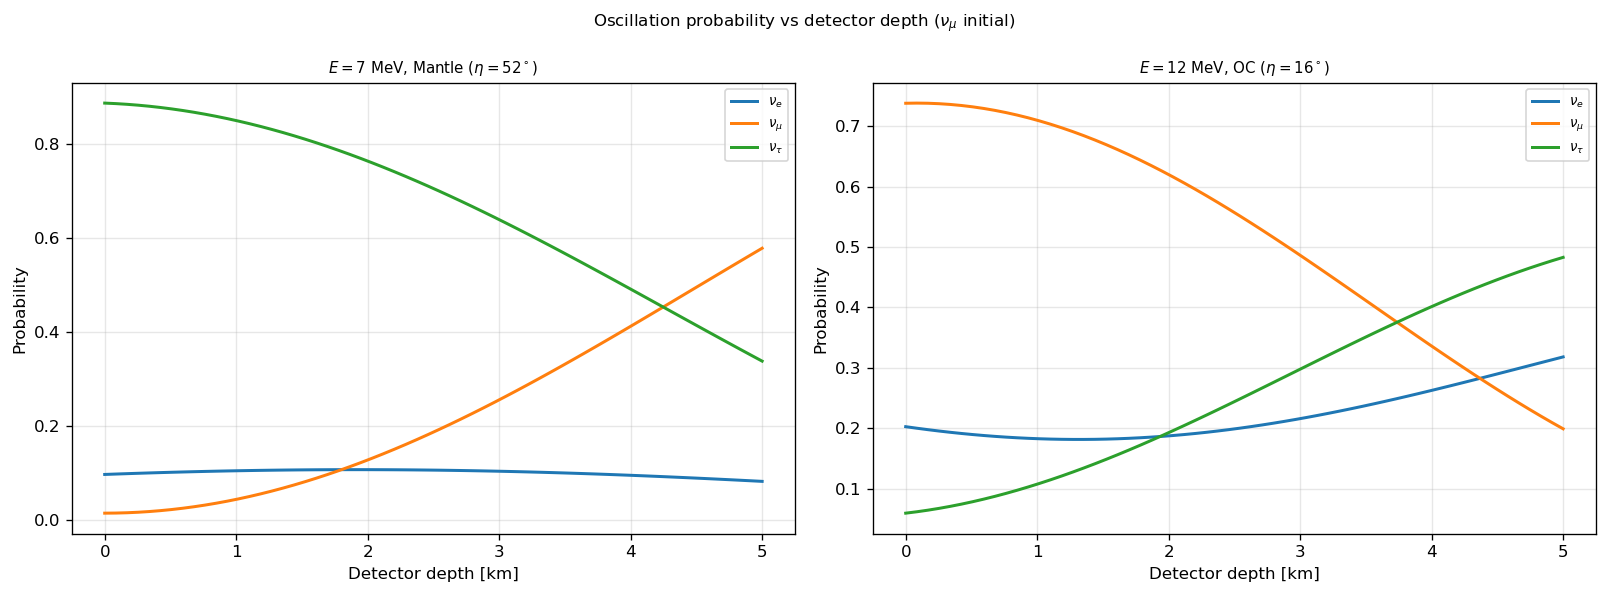

v:\output\analysis\earth\ep2_fig101_depth_fixed.png


In [18]:
DEPTH_GRID_M = np.linspace(0.0, 5000.0, 60)
DEPTH_CASES  = [
    (7.0,  eta_mantle, rf'$E=7$ MeV, Mantle ($\eta={math.degrees(eta_mantle):.0f}^\circ$)'),
    (12.0, eta_oc,     rf'$E=12$ MeV, OC ($\eta={math.degrees(eta_oc):.0f}^\circ$)'),
]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0), sharey=False)
for ax, (E_MeV, eta_val, case_label) in zip(axes, DEPTH_CASES):
    E_t   = torch.tensor(E_MeV,  dtype=ctx.dtype, device=ctx.device)
    eta_t = torch.tensor(eta_val, dtype=ctx.dtype, device=ctx.device)
    P_depth = np.zeros((len(DEPTH_GRID_M), 3))
    for id_, depth_m in enumerate(DEPTH_GRID_M):
        P = pearth_analytical(state_mu, earth_even, oscillation, E_t, eta_t,
                              depth_m, massbasis=False)
        P_depth[id_] = P.detach().cpu().numpy()
    for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
        ax.plot(DEPTH_GRID_M / 1e3, P_depth[:, f], color=fcol, lw=1.8, label=flabel)
    ax.set_xlabel('Detector depth [km]')
    ax.set_ylabel('Probability')
    ax.set_title(case_label, fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle(r'Oscillation probability vs detector depth ($\nu_\mu$ initial)',
             fontsize=10)
fig.tight_layout()
save_and_show('ep2_fig101_depth_fixed.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

### 9.2 Peak-to-Peak Depth Sensitivity vs Nadir Angle

For each nadir angle the depth scan from 0 to 5 km is repeated at fixed energy ($E = 10$ MeV), and the peak-to-peak variation $\Delta P_{\rm pk} = \max_d P - \min_d P$ is recorded. This summary plot shows which nadir angles are most and least affected by the detector depth uncertainty.

**Expected results:** 
- Sensitivity peaks at nadir angles where the oscillation length matched to the 5-km depth range $\sim \Delta d \cdot \cos\eta$.
- Deep-core trajectories are often less sensitive because the depth perturbation is small relative to the total chord length.

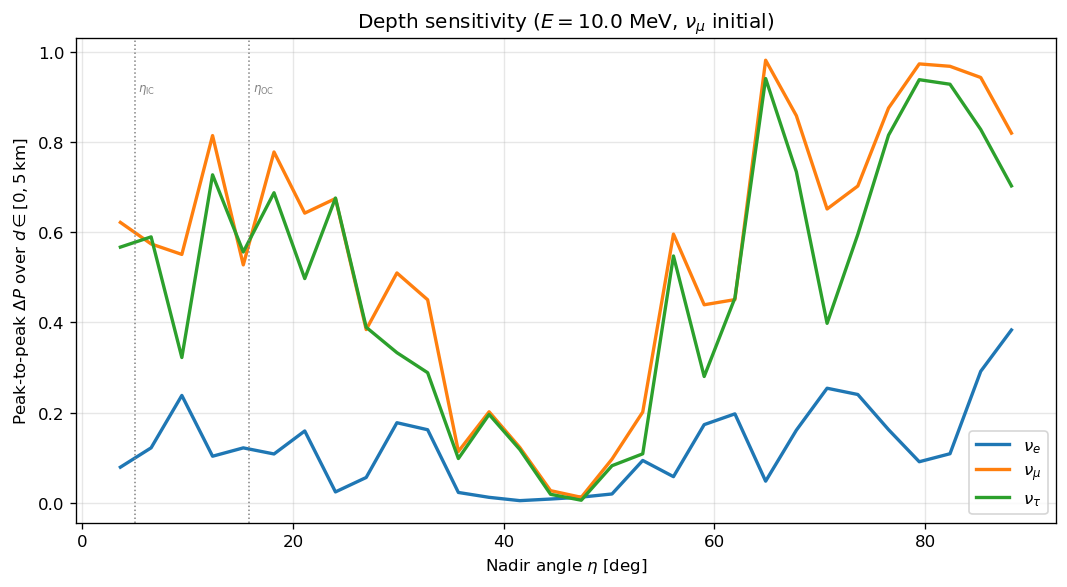

v:\output\analysis\earth\ep2_fig102_depth_eta.png


In [19]:
ETA_DEPTH_GRID = np.linspace(0.02 * math.pi, 0.49 * math.pi, 30)
DEPTH_FINE_M  = np.linspace(0.0, 5000.0, 40)
E_DEPTH_MEV   = 10.0
E_t_depth     = torch.tensor(E_DEPTH_MEV, dtype=ctx.dtype, device=ctx.device)

pk2pk = np.zeros((len(ETA_DEPTH_GRID), 3))
for ie, eta in enumerate(ETA_DEPTH_GRID):
    eta_t = torch.tensor(eta, dtype=ctx.dtype, device=ctx.device)
    P_d   = np.zeros((len(DEPTH_FINE_M), 3))
    for id_, depth_m in enumerate(DEPTH_FINE_M):
        P = pearth_analytical(state_mu, earth_even, oscillation,
                              E_t_depth, eta_t, depth_m, massbasis=False)
        P_d[id_] = P.detach().cpu().numpy()
    pk2pk[ie] = P_d.max(axis=0) - P_d.min(axis=0)

fig, ax = plt.subplots(figsize=(9, 5.0))
for f, (flabel, fcol) in enumerate(zip(FLAVOUR_LABELS, FLAVOUR_COLORS)):
    ax.plot(np.degrees(ETA_DEPTH_GRID), pk2pk[:, f], color=fcol, lw=2, label=flabel)
for eta_c, dlabel in [(eta_ic_deg, r'$\eta_{\rm IC}$'), (eta_oc_deg, r'$\eta_{\rm OC}$')]:
    ax.axvline(eta_c, color='gray', ls=':', lw=0.9)
    ax.text(eta_c + 0.3, pk2pk.max() * 0.95, dlabel, fontsize=7, color='gray', va='top')
ax.set_xlabel(r'Nadir angle $\eta$ [deg]')
ax.set_ylabel(r'Peak-to-peak $\Delta P$ over $d \in [0, 5\,\rm km]$')
ax.set_title(rf'Depth sensitivity ($E={E_DEPTH_MEV}$ MeV, $\nu_\mu$ initial)')
ax.legend()
fig.tight_layout()
save_and_show('ep2_fig102_depth_eta.png', fig,
              output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 10. Summary

### API Coverage

| Function | Notebook section | Key parameters shown |
|----------|-----------------|---------------------|
| `pearth_numerical(full_oscillation=True)` | §3.1, §3.2, §3.3 | all 3 initial states, 4 nadir angles, 4 energies |
| `pearth_analytical` | §4, §5, §6.1, §8, §9 | η-scan, E-scan, comparison, model diff, depth |
| `earth_evolutor` | §6.2, §7.1, §7.2 | $U(E)$, $U(E,\eta)$ 2D, reunitarize |
| `earth_evolutor_from_zenith` | §7.3 | zenith-angle interface |

### Key Physical Results

1. **Chord oscillations** (§3): The density jumps at ICB and CMB appear as visible kinks in $P_\alpha(x)$. Higher-energy neutrinos complete fewer oscillation cycles over the same chord.

2. **Analytical accuracy** (§6.1): `pearth_analytical` agrees with `pearth_numerical` at $n_{\rm steps}=120$ to better than $10^{-3}$ over most of the $(E,\eta)$ plane.

3. **Evolution operator** (§7): `earth_evolutor` with independent 1D grids provides a direct vectorised route to all 9 matrix elements $|U_{\alpha\beta}|^2$ over the full $(E,\eta)$ plane.

4. **Density model difference** (§8): $|\Delta P|_{\rm PREM - even} < 0.05$ everywhere; the largest residuals are near the inner-core critical angle.

5. **Depth sensitivity** (§9): The peak-to-peak variation in $P$ over $d \in [0, 5]$ km reaches $\sim 0.01$–$0.05$ at nadir angles where the oscillation length matches the depth range.


In [20]:
print('Summary — Earth Analysis 2: Earth Propagation')
print('=' * 60)
print(f'Oscillation preset      : _SM_NUFIT52_NO')
print(f'Dm21                    : {float(oscillation.DeltamSq21):.4e} eV²')
print(f'Dm3l                    : {float(oscillation.DeltamSq3l):.4e} eV²')
print(f'Detector depth          : {EARTH_DEPTH_M:.0f} m')
print()
print('Representative nadir angles:')
for eta_val, label, _ in NAMED_ETAS:
    L_km = 2.0 * R_E_KM * math.cos(eta_val)
    rmin = R_E_KM * math.sin(eta_val)
    print(f'  {label:45s}  L={L_km:7.0f} km  r_min={rmin:7.0f} km')
print()
print('Method comparison (nu_mu initial, inner-core trajectory):')
print(f'  Max |P_an - P_num| / max(P_num, 1e-4)  : {max_rel_diff.max():.3e}')
print()
print('Unitarity deviations at inner-core trajectory:')
print(f'  No reunitarize   : max eps_U = {eps_plain.max():.3e}')
print(f'  With reunitarize : max eps_U = {eps_reunit.max():.3e}')
print()
print('Density model comparison (PREM vs even-power):')
print(f'  Max |delta_P|    : {vabs:.4f}')
print(f'  RMS delta_P      : {np.sqrt(np.mean(delta_P**2)):.4f}')

Summary — Earth Analysis 2: Earth Propagation
Oscillation preset      : _SM_NUFIT52_NO
Dm21                    : 7.4100e-05 eV²
Dm3l                    : 2.5110e-03 eV²
Detector depth          : 2000 m

Representative nadir angles:
  IC ($\eta=4.9^\circ$)                          L=  12694 km  r_min=    550 km
  OC ($\eta=15.8^\circ$)                         L=  12258 km  r_min=   1740 km
  Mantle ($\eta=52.0^\circ$)                     L=   7841 km  r_min=   5022 km
  Crust ($\eta=82.1^\circ$)                      L=   1759 km  r_min=   6310 km

Method comparison (nu_mu initial, inner-core trajectory):
  Max |P_an - P_num| / max(P_num, 1e-4)  : 2.517e-01

Unitarity deviations at inner-core trajectory:
  No reunitarize   : max eps_U = 2.395e-04
  With reunitarize : max eps_U = 5.128e-16

Density model comparison (PREM vs even-power):
  Max |delta_P|    : 0.0238
  RMS delta_P      : 0.0033
